in this notebook, different componenets to analyse the flight behaviour will be tested

In [1]:
import os
from datetime import datetime, timedelta
from typing import Tuple
import pandas as pd

import matplotlib.pyplot as plt
from dotenv import load_dotenv

import logger
from pats_service import PatsService, PatsServiceError
from plot_examples import ExamplePlots


## Username and login

In [2]:
logger.init_logger(logger=logger.logger)

load_dotenv()

user = os.getenv("pats_user")
passw = os.getenv("pats_passw")

service = PatsService(user, passw)


* INFO  - Successfully retrieved API token from server: https://pats-c.com - pats_service.69


In [8]:
sections = service.download_sections()
detection_classes = service.download_detection_classes()


* INFO  - Successfully sections from pats server - pats_service.170
* INFO  - Successfully retrieved detection classes from pats server - pats_service.111


In [9]:
sections = sections[0]

for insect in sections["detection_classes"]:
    print(insect["id"], "-", insect["label"])


64 - No size
1 - Chrysodeixis chalcites
3 - Tuta absoluta
12 - Bombus terrestris
63 - Anomalies


In [10]:
sections = service.download_sections()

print(sections)
print("Available Sections for your account:")

for index, section in enumerate(sections):
    name = section.get("name", "Unnamed Section")
    print(f"Index [{index}] -> Section ID: {section['id']} | Name: {name}")

* INFO  - Successfully sections from pats server - pats_service.170


[{'id': 509, 'name': '', 'greenhouse_name': '1', 'label': '1', 'customer_name': 'Tomatoworld', 'crop': 'Tomato', 'detection_classes': [{'id': 64, 'label': 'No size', 'translations': {'SHORT': 'No size'}, 'available_in_c': 1, 'available_in_trapeye': 0, 'available_in_manual_scouting': 0, 'pest_insect': 0, 'pest_animal': 0, 'pest_fungus': False, 'pest_bacteria': False, 'pest_virus': False, 'natural_enemy': 0, 'pollinator': 0, 'beneficial': 0, 'invert_colors': 0, 'c_level_1': 5, 'c_level_2': 15, 'c_level_3': 30, 'c_level_4': 50, 'trapeye_level_1': None, 'trapeye_level_2': None, 'trapeye_level_3': None, 'trapeye_level_4': None, 'bb_label': None}, {'id': 1, 'label': 'Chrysodeixis chalcites', 'translations': {'LA': 'Chrysodeixis chalcites', 'NL': 'Turkse Mot (Chrysodeixis)', 'EN': 'Tomato looper (Chrysodeixis)', 'FR': 'Noctuelle de la tomate (Chrysodeixis)', 'DE': 'Tomateneule (Chrysodeixis)', 'SHORT': 'Tomato looper / Turkse mot', 'NO': 'Tomatfly (Chrysodeixis)', 'SV': 'Tomatfly (Chrysodeixi

In [11]:

example_section = sections[0]   # of kies een andere index
section_id = example_section["id"]

print("Using section_id:", section_id)

Using section_id: 509


In [12]:
spots = service.download_spots(section_id)

for s in spots["c"]:
    print(
        "row:", s["row_id"],
        "| post:", s["post_id"],
        "| system:", s["system_id"]
    )



* INFO  - Successfully retrieved spots from pats servers - pats_service.229


row: 6 | post: 1 | system: 900
row: 13 | post: 1 | system: 939


In [13]:
some_system_id = spots["c"][0]["system_id"]

some_system_id

900

## Hive-return analysis for 2026-04-19

A "hive return" is any flight track whose **last** valid `(posX_insect, posY_insect, posZ_insect)` sample is within a tolerance of the hive position.


In [11]:
from datetime import datetime
from pathlib import Path
import numpy as np
import pandas as pd

# --- Parameters you can tweak ----------------------------------------------
TARGET_DATE = datetime(2026, 4, 13)

# Hive positions per PATS-C system.
# Each camera has its OWN local coordinate frame, so each one gets its
# own hive position.
hive_900_pos = np.array([-0.04, -0.665, -1.195])     # system_id 900 (row 6)
hive_939_pos = np.array([ -0.086, -0.828, -1.045 ])      # system_id 939 (row 13) - TODO: fill in actual xyz

HIVE_BY_SYSTEM = {
    900: hive_900_pos,
    939: hive_939_pos,
}

TOL = 0.1                                       # metres, sphere radius around hive
BUMBLEBEE_CLASS_ID = 12                         # "Bombus terrestris"

# Which PATS-C sensor(s) to analyse.
#   "both"       -> use every PATS-C sensor in the section
#   900 or 939   -> only that specific camera (system_id)
SPOT_SELECTION = "900"

# Backwards-compat default hive: whichever camera is selected.
# (Classification uses HIVE_BY_SYSTEM per track, but several cells still
# reference HIVE_POS for a single-camera view / debug printing.)
if SPOT_SELECTION == "both":
    HIVE_POS = hive_900_pos        # arbitrary default for plotting axes
else:
    try:
        _sel_int = int(SPOT_SELECTION)
    except (TypeError, ValueError):
        raise ValueError(
            "SPOT_SELECTION must be 'both' or a system_id (int). "
            + "Got " + repr(SPOT_SELECTION) + "."
        )
    if _sel_int not in HIVE_BY_SYSTEM:
        raise ValueError(
            "No hive position defined for system_id=" + str(_sel_int)
            + ". Add it to HIVE_BY_SYSTEM."
        )
    HIVE_POS = HIVE_BY_SYSTEM[_sel_int]

# Local cache (one CSV per uid) so we don't re-download each run.
_sel_label = "both" if SPOT_SELECTION == "both" else f"system_{SPOT_SELECTION}"
CACHE_ROOT    = Path("cache") / f"flight_data_{TARGET_DATE.strftime('%Y-%m-%d')}_{_sel_label}"
TRACKS_DIR    = CACHE_ROOT / "tracks"
DETECTIONS_CSV = CACHE_ROOT / "detections.csv"

# Permanent export location.
EXPORT_DIR = (Path("..") / ".." / ".." / "data"
              / f"{TARGET_DATE.strftime('%Y-%m-%d')}_{_sel_label}")

FORCE_REFRESH = False   # True = ignore cache and re-download everything
# ---------------------------------------------------------------------------

TRACKS_DIR.mkdir(parents=True, exist_ok=True)

day_start = TARGET_DATE.replace(hour=0,  minute=0,  second=0, microsecond=0)
day_end   = TARGET_DATE.replace(hour=23, minute=59, second=59, microsecond=0)

# Resolve the spot selection against what spots["c"] gave us.
if SPOT_SELECTION == "both":
    selected_spots = list(spots["c"])
else:
    _target_id = int(SPOT_SELECTION)
    selected_spots = [s for s in spots["c"] if s.get("system_id") == _target_id]
    if not selected_spots:
        raise ValueError(
            "No PATS-C spot with system_id=" + str(_target_id)
            + ". Available: " + str([s['system_id'] for s in spots['c']])
        )

print(f"Window : {day_start}  ->  {day_end}")
print(f"Hive(s): " + ", ".join(
    f"sys {sid}={h.tolist()}"
    for sid, h in HIVE_BY_SYSTEM.items()
    if SPOT_SELECTION == "both" or int(SPOT_SELECTION) == sid
))
print(f"TOL    : {TOL} m (spherical)")
print(f"Spots  : {[s['system_id'] for s in selected_spots]}  (selection={SPOT_SELECTION!r})")
print(f"Cache  : {CACHE_ROOT.resolve()}")
print(f"Export : {EXPORT_DIR.resolve()}")


Window : 2026-04-13 00:00:00  ->  2026-04-13 23:59:59
Hive(s): sys 900=[-0.04, -0.665, -1.195]
TOL    : 0.1 m (spherical)
Spots  : [900]  (selection='900')
Cache  : /Users/jaspe/Projects/Claude/Bumblebee-monitoring/src/flight_analysis/pats/cache/flight_data_2026-04-13_system_900
Export : /Users/jaspe/Projects/Claude/Bumblebee-monitoring/data/2026-04-13_system_900


### 1. Get all bumblebee detections for that day

We loop over every PATS-C spot in the section and ask the server for the detection summaries (one row per flight) on 2026-04-19. Each row has a `uid` we need to pull the track.


In [12]:
# Cached detections: skip the server call if we already have today's CSV.
if DETECTIONS_CSV.exists() and not FORCE_REFRESH:
    detections = pd.read_csv(DETECTIONS_CSV)
    print(f"Loaded cached detections from {DETECTIONS_CSV}  ({len(detections)} rows)")
else:
    detection_frames = []
    for spot in selected_spots:
        row_id    = spot.get("row_id")
        post_id   = spot.get("post_id")
        system_id = spot.get("system_id") if (row_id is None or post_id is None) else None

        df = service.download_c_detection_features(
            section_id         = section_id,
            row_id             = row_id,
            post_id            = post_id,
            system_id          = system_id,
            detection_class_id = BUMBLEBEE_CLASS_ID,
            start_date         = day_start,
            end_date           = day_end,
        )
        if df.empty:
            print(f"  row={row_id} post={post_id} system={spot.get('system_id')}: 0 detections")
            continue

        df["row_id"]    = row_id
        df["post_id"]   = post_id
        df["system_id"] = spot.get("system_id")
        detection_frames.append(df)
        print(f"  row={row_id} post={post_id} system={spot.get('system_id')}: {len(df)} detections")

    detections = pd.concat(detection_frames, ignore_index=True) if detection_frames else pd.DataFrame()
    detections.to_csv(DETECTIONS_CSV, index=False)
    print(f"Saved detections -> {DETECTIONS_CSV}")

print(f"\nTotal bumblebee detections on {TARGET_DATE.date()}: {len(detections)}")
detections.head(155)


Loaded cached detections from cache/flight_data_2026-04-13_system_900/detections.csv  (369 rows)

Total bumblebee detections on 2026-04-13: 369


,datetime,dist_traject,dist_traveled,duration,light_level,post_id,row_id,size,start_datetime,uid,vel_max,vel_mean,vel_std,system_id
0,20260413_133131,2.880652,0.670166,1.802514,0.636528,1,6,0.011906,"Mon, 13 Apr 2026 11:31:31 GMT",1001029,2.428028,1.506490,0.496023,900
1,20260413_133145,1.152599,0.352945,3.538431,0.636580,1,6,0.010058,"Mon, 13 Apr 2026 11:31:45 GMT",1001060,1.121195,0.255782,0.265606,900
2,20260413_133147,3.844862,0.668507,2.692764,0.637064,1,6,0.011050,"Mon, 13 Apr 2026 11:31:47 GMT",1001062,2.148426,1.018162,0.384496,900
3,20260413_133153,0.866176,0.260593,1.402189,0.637469,1,6,0.011714,"Mon, 13 Apr 2026 11:31:53 GMT",1001068,1.106127,0.448541,0.251247,900
4,20260413_133248,3.445201,2.910825,1.480278,0.638916,1,6,0.010733,"Mon, 13 Apr 2026 11:32:48 GMT",1001155,3.826351,2.222211,0.447140,900
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
150,20260413_135932,2.149653,0.688798,6.565662,0.651472,1,6,0.009302,"Mon, 13 Apr 2026 11:59:32 GMT",1002164,1.707934,0.251855,0.403959,900
151,20260413_135937,1.411340,0.392124,1.546775,0.651509,1,6,0.012399,"Mon, 13 Apr 2026 11:59:37 GMT",1002167,1.340824,0.773623,0.229284,900
152,20260413_140019,1.235929,0.875205,2.659536,0.651404,1,6,0.011411,"Mon, 13 Apr 2026 12:00:19 GMT",1002187,1.528129,0.404570,0.476854,900
153,20260413_140032,2.220451,0.515268,1.702590,0.651584,1,6,0.012798,"Mon, 13 Apr 2026 12:00:32 GMT",1002192,1.982751,0.684686,0.447357,900


### 2. Download the flight track for each detection

`download_c_flight_track` returns one row per video frame with `posX_insect / posY_insect / posZ_insect`.


In [13]:
tracks = {}   # uid -> DataFrame

for uid in detections["uid"].tolist():
    uid = int(uid)
    track_path = TRACKS_DIR / f"{uid}.csv"

    if track_path.exists() and not FORCE_REFRESH:
        trk = pd.read_csv(track_path)
    else:
        try:
            trk = service.download_c_flight_track(section_id, uid)
        except Exception as e:
            print(f"  uid={uid}: FAILED ({e})")
            continue
        if trk.empty:
            # Write an empty marker so we don't retry next time
            trk.to_csv(track_path, index=False)
            continue
        trk.to_csv(track_path, index=False)

    if trk.empty:
        continue
    tracks[uid] = trk

print(f"Have {len(tracks)} non-empty tracks ({sum(1 for p in TRACKS_DIR.glob('*.csv'))} files on disk).")


Have 369 non-empty tracks (369 files on disk).


### Downlaoding video

In [14]:
# 1. Define the specific UID you are looking for
target_uid = 1331699

print(f"Requesting video for UID {target_uid}... (This takes about 30 seconds)")

# 2. Download the video data using your 'service' and 'section_id' variables
mkv_data = service.download_c_video(section_id, target_uid)

# 3. Save the downloaded data to an .mkv file named after the insect
filename = f"video_{target_uid}.mkv"
with open(filename, "wb") as file:
    file.write(mkv_data)
    
print(f"Done! Video saved as {filename}")

Requesting video for UID 1331699... (This takes about 30 seconds)


* INFO  - Successfully downloaded c video from detection: 1331699 - pats_service.653


Done! Video saved as video_1331699.mkv


#### Quick pandas check

In [29]:
# by uid (exactly what PATS returned)
display(detections[detections["uid"] == 1002919])

# by local-time substring (any part of 20260419_125330 works)
display(detections[detections["datetime"].str.contains("133355")])

"""# by hour/minute only
detections[detections["datetime"].str.endswith("_125330")]
"""
"""# by date, just the bees seen between 12:00 and 13:00
between = detections["datetime"].str[:11] + detections["datetime"].str[-4:]  # not needed usually
detections[detections["datetime"].str.slice(9, 13) == "1253"]
"""
"""# .query is also nice for uid
detections.query("uid == 1332812")"""



,datetime,dist_traject,dist_traveled,duration,light_level,post_id,row_id,size,start_datetime,uid,vel_max,vel_mean,vel_std,system_id
330,20260413_145947,1.515387,0.200942,4.529061,0.648045,1,6,0.010234,"Mon, 13 Apr 2026 12:59:47 GMT",1002919,2.060371,0.220882,0.270548,900


,datetime,dist_traject,dist_traveled,duration,light_level,post_id,row_id,size,start_datetime,uid,vel_max,vel_mean,vel_std,system_id


'# .query is also nice for uid\ndetections.query("uid == 1332812")'

### 3. Classify each track: hive return or not

For each track we take the **last sample with a valid position** (`pos_valid_insect == 1` when the column exists, otherwise the final row) and check whether each of x/y/z is within `TOL` of the hive coordinate.


In [14]:
def valid_xyz(trk):
    """(N, 3) array of valid positions in a track, or None if there aren't any."""
    if trk is None or trk.empty:
        return None
    if "pos_valid_insect" in trk.columns:
        valid = trk[trk["pos_valid_insect"] == 1]
    else:
        valid = trk
    if valid.empty:
        return None
    return valid[["posX_insect", "posY_insect", "posZ_insect"]].to_numpy(dtype=float)



def last_valid_xyz(trk):
    """Last valid (x, y, z) of a track, or None."""
    xyz = valid_xyz(trk)
    return None if xyz is None else xyz[-1]


# How many trailing frames to look at. PATS-C often loses the track a few
# frames before the bee actually reaches the hive, so checking only the
# very last point is too strict.
TAIL_FRAMES = 10


def min_distance_to_hive(trk, hive):
    """Smallest Euclidean (spherical) distance between the last TAIL_FRAMES
    valid samples and the hive position. Returns np.inf if no valid samples."""
    xyz = valid_xyz(trk)
    if xyz is None:
        return float("inf")
    tail = xyz[-TAIL_FRAMES:]
    return float(np.min(np.linalg.norm(tail - hive, axis=1)))


def is_hive_return(trk, hive, tol=TOL):
    """True if the bee came within `tol` metres (sphere radius) of the hive
    during the last TAIL_FRAMES valid samples."""
    return min_distance_to_hive(trk, hive) <= tol


# Look up which camera each uid came from, so each track is compared to the
# right hive.
uid_to_system = (detections.set_index("uid")["system_id"]
                 .astype("Int64").to_dict())


def hive_for_uid(uid):
    sys_id = uid_to_system.get(uid)
    if sys_id is None or pd.isna(sys_id):
        return HIVE_POS  # fall back to the notebook default
    return HIVE_BY_SYSTEM.get(int(sys_id), HIVE_POS)


rows = []
for uid, trk in tracks.items():
    hive = hive_for_uid(uid)
    xyz  = last_valid_xyz(trk)
    rows.append({
        "uid"          : uid,
        "system_id"    : uid_to_system.get(uid),
        "n_frames"     : len(trk),
        "last_x"       : None if xyz is None else xyz[0],
        "last_y"       : None if xyz is None else xyz[1],
        "last_z"       : None if xyz is None else xyz[2],
        "hive_x"       : hive[0],
        "hive_y"       : hive[1],
        "hive_z"       : hive[2],
        "min_dist_hive": min_distance_to_hive(trk, hive),
        "hive_return"  : is_hive_return(trk, hive),
    })

results = (pd.DataFrame(rows)
           .sort_values(["hive_return", "min_dist_hive"], ascending=[False, True])
           .reset_index(drop=True))
results


,uid,system_id,n_frames,last_x,last_y,last_z,hive_x,hive_y,hive_z,min_dist_hive,hive_return
0,1001877,900,587,-0.036545,-0.667439,-1.19207,-0.04,-0.665,-1.195,0.005145,True
1,1002788,900,152,-0.030570,-0.661408,-1.20608,-0.04,-0.665,-1.195,0.012818,True
2,1002039,900,268,-0.030051,-0.656513,-1.19745,-0.04,-0.665,-1.195,0.013305,True
3,1001882,900,116,-0.054331,-0.665262,-1.18780,-0.04,-0.665,-1.195,0.016040,True
4,1002436,900,394,-0.024118,-0.657167,-1.19839,-0.04,-0.665,-1.195,0.018030,True
...,...,...,...,...,...,...,...,...,...,...,...
364,1003067,900,162,-3.855530,-2.103910,-6.75640,-0.04,-0.665,-1.195,5.325866,False
365,1002887,900,139,3.079370,-2.777720,-7.16138,-0.04,-0.665,-1.195,5.613891,False
366,1001728,900,173,2.827700,-1.428060,-7.82920,-0.04,-0.665,-1.195,5.963812,False
367,1003073,900,149,0.324995,-2.932840,-9.41697,-0.04,-0.665,-1.195,6.624955,False


In [15]:
n_total   = len(results)
n_return  = int(results["hive_return"].sum())
print(f"Hive returns on {TARGET_DATE.date()}: {n_return} / {n_total} tracks")
if n_total:
    print(f"Return rate: {n_return / n_total:.1%}")


Hive returns on 2026-04-13: 51 / 369 tracks
Return rate: 13.8%


### 4. Quick visual sanity check

Plot the last positions, colouring the hive-returners and drawing the tolerance box around the hive.


(plot) dropped 50 outlier last-position(s) beyond 5.0 m from any hive


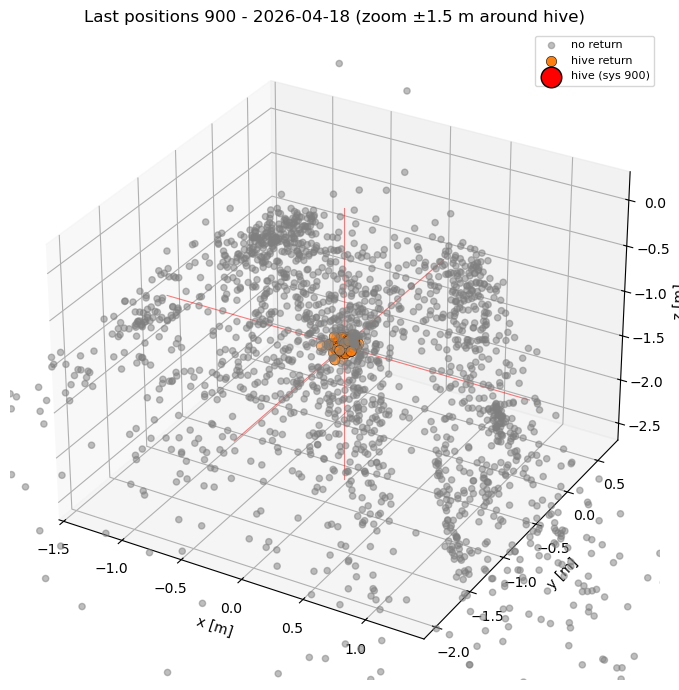

In [26]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401  (registers 3d projection)

# -- Plot controls -----------------------------------------------------------
ZOOM_RADIUS    = 1.5    # axis half-width around the hive(s), in metres
OUTLIER_RADIUS = 5.0    # drop last-positions further than this from any hive
# ---------------------------------------------------------------------------

# Which hives are "in play" for this run.
if SPOT_SELECTION == "both":
    hives_to_show = [("hive (sys 900)", hive_900_pos),
                     ("hive (sys 939)", hive_939_pos)]
else:
    hives_to_show = [(f"hive (sys {SPOT_SELECTION})", HIVE_POS)]

hive_arr = np.stack([h for _, h in hives_to_show])   # (k, 3)

fig = plt.figure(figsize=(9, 7))
ax  = fig.add_subplot(111, projection="3d")

# ---- Scatter the last positions first (so the hive paints on top). --------
if not results.empty:
    res = results.dropna(subset=["last_x", "last_y", "last_z"]).copy()

    # Drop extreme outliers so the axes don't blow up.
    pts = res[["last_x", "last_y", "last_z"]].to_numpy(dtype=float)
    if len(pts):
        # distance from each point to its nearest hive
        d2 = np.min(np.linalg.norm(
            pts[:, None, :] - hive_arr[None, :, :], axis=-1), axis=1)
        res = res[d2 <= OUTLIER_RADIUS]

    n_dropped = len(results) - len(res)
    if n_dropped:
        print(f"(plot) dropped {n_dropped} outlier last-position(s) "
              f"beyond {OUTLIER_RADIUS} m from any hive")

    ret  = res[res["hive_return"]]
    miss = res[~res["hive_return"]]
    ax.scatter(miss["last_x"], miss["last_y"], miss["last_z"],
               c="tab:gray", s=20, alpha=0.5, label="no return")
    ax.scatter(ret["last_x"],  ret["last_y"],  ret["last_z"],
               c="tab:orange", s=55, edgecolors="black", linewidths=0.4,
               label="hive return")

# ---- Now draw the hive(s) on top. -----------------------------------------
def plot_hive(ax, pos, tol, label, xlim, ylim, zlim):
    """Big red dot + wireframe sphere + crosshair lines through the hive."""
    # Crosshair lines: guaranteed visible no matter the view angle.
    ax.plot(xlim, [pos[1]] * 2, [pos[2]] * 2, c="red", lw=0.8, alpha=0.5)
    ax.plot([pos[0]] * 2, ylim, [pos[2]] * 2, c="red", lw=0.8, alpha=0.5)
    ax.plot([pos[0]] * 2, [pos[1]] * 2, zlim, c="red", lw=0.8, alpha=0.5)
    # Wireframe tolerance sphere.
    u = np.linspace(0, 2 * np.pi, 20)
    v = np.linspace(0, np.pi, 12)
    xs = pos[0] + tol * np.outer(np.cos(u), np.sin(v))
    ys = pos[1] + tol * np.outer(np.sin(u), np.sin(v))
    zs = pos[2] + tol * np.outer(np.ones_like(u), np.cos(v))
    ax.plot_wireframe(xs, ys, zs, color="red", alpha=0.6, linewidth=0.7)
    # The red dot itself.
    ax.scatter(pos[0], pos[1], pos[2], c="red", marker="o",
               s=220, edgecolors="black", linewidths=1.0, label=label,
               depthshade=False)


# Zoom around the hive(s).
xlim = (hive_arr[:, 0].min() - ZOOM_RADIUS, hive_arr[:, 0].max() + ZOOM_RADIUS)
ylim = (hive_arr[:, 1].min() - ZOOM_RADIUS, hive_arr[:, 1].max() + ZOOM_RADIUS)
zlim = (hive_arr[:, 2].min() - ZOOM_RADIUS, hive_arr[:, 2].max() + ZOOM_RADIUS)
ax.set_xlim(xlim)
ax.set_ylim(ylim)
ax.set_zlim(zlim)

for label, pos in hives_to_show:
    plot_hive(ax, pos, TOL, label, xlim, ylim, zlim)

ax.set_xlabel("x [m]")
ax.set_ylabel("y [m]")
ax.set_zlabel("z [m]")
ax.set_title(f"Last positions {SPOT_SELECTION} - {TARGET_DATE.date()} "
             f"(zoom ±{ZOOM_RADIUS} m around hive)")
ax.legend(loc="best", fontsize=8)
plt.tight_layout()
plt.show()


### 5. Export to `data/flight_data/`

Permanent copy of the results (next to the repo's other data). Safe to commit-ignore; see `.gitignore`.


In [16]:
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

# 1. Detection summaries
detections.to_csv(EXPORT_DIR / "detections.csv", index=False)

# 2. All flight tracks concatenated, with a detection_uid column linking back
if tracks:
    track_frames = []
    for uid, trk in tracks.items():
        t = trk.copy()
        t["detection_uid"] = uid
        # propagate the camera id so we can filter per sensor later
        sysids = detections.loc[detections["uid"] == uid, "system_id"]
        t["system_id"] = sysids.iloc[0] if len(sysids) else None
        track_frames.append(t)
    all_tracks = pd.concat(track_frames, ignore_index=True)
    all_tracks.to_csv(EXPORT_DIR / "flight_tracks.csv", index=False)
else:
    all_tracks = pd.DataFrame()
    print("No non-empty tracks to export.")

# 3. Hive-return classification
results.to_csv(EXPORT_DIR / "hive_return_results.csv", index=False)

print(f"Wrote to {EXPORT_DIR.resolve()}:")
for f in sorted(EXPORT_DIR.iterdir()):
    size_kb = f.stat().st_size / 1024
    print(f"  {f.name}  ({size_kb:,.1f} KB)")


Wrote to /Users/jaspe/Projects/Claude/Bumblebee-monitoring/data/2026-04-13_system_900:
  detections.csv  (77.0 KB)
  flight_tracks.csv  (19,010.4 KB)
  hive_return_results.csv  (32.1 KB)


## 5. Wipe + refetch a specific date

If a download came back partial (e.g. only a handful of tracks on a day you'd expect to be busy, like 2026-04-23 with `n_tracks = 10` for system 900 and `14` for system 939), use this cell to delete the cache **and** the export folder for one or more `(date, system)` pairs, then re-run section 3 (Download loop) above.

The fast-path skip in `export_for` checks whether both the cache files and the export files already exist - if either is gone, it re-downloads from PATS.


In [ ]:
import shutil

## Check

# --- Edit these two lists, then run the cell ----------------------------
DATES_TO_REFETCH   = [date(2026, 5, 8)]   # add more dates as needed
SYSTEMS_TO_REFETCH = SYSTEMS               # default = both cameras from the config
# ------------------------------------------------------------------------

wiped = 0
for d in DATES_TO_REFETCH:
    for sid in SYSTEMS_TO_REFETCH:
        folder_name = f"{d.strftime('%Y-%m-%d')}_system_{sid}"
        cache_dir   = CACHE_ROOT_BASE / f"flight_data_{folder_name}"
        export_dir  = EXPORT_ROOT     / folder_name

        for p in (cache_dir, export_dir):
            if p.exists():
                shutil.rmtree(p)
                print(f"  wiped  {p}")
                wiped += 1
            else:
                print(f"  clean  {p}")

print(f"\nDone. Wiped {wiped} folder(s).")
print("Now re-run section 3 (Download loop) to re-fetch from PATS.")


### Debug: inspect one specific detection

Useful when you know a flight *should* count as a hive return (e.g. you watched the video) but the notebook says it doesn't. Enter the detection's timestamp and we'll print:
- which row of `detections` it matches (so you get the `uid` + `system_id`)
- the tail of that flight track (so you see the raw last samples)
- the last valid `(x, y, z)` and its distance from the hive

If the last point looks way off the hive coordinates you typed in, the likely culprits are:
1. **Each camera has its own local coordinate frame.** `system=900` and `system=939` don't share axes. Hive coords pulled from a `system=900` video won't apply to a `system=939` track.
2. The axis you think is "up" may be one of the others — PATS-C uses +x right, +y down, +z forward from the camera.
3. The per-axis tolerance of 0.1 m is a box, not a sphere. A flight that stops 0.15 m away in just one axis won't count.


In [18]:
# --- Pick a detection by its timestamp (format: YYYYmmdd_HHMMSS) -------------
TARGET_DT_STR = "20260419_125330"
# ---------------------------------------------------------------------------

# detections['datetime'] is either a full datetime or the start_datetime string.
# We'll search both columns to be safe.
candidates = detections.copy()
mask = False
for col in ("datetime", "start_datetime"):
    if col in candidates.columns:
        col_str = candidates[col].astype(str)
        mask = mask | col_str.str.contains(TARGET_DT_STR, na=False)
hits = candidates[mask] if hasattr(mask, "any") else pd.DataFrame()

if hits.empty:
    # Fall back: parse the timestamp and look for detections within +/- 1 minute.
    t0 = pd.to_datetime(TARGET_DT_STR, format="%Y%m%d_%H%M%S")
    for col in ("datetime", "start_datetime"):
        if col in detections.columns:
            parsed = pd.to_datetime(detections[col], errors="coerce", utc=True).dt.tz_localize(None)
            hits = detections[(parsed - t0).abs() < pd.Timedelta("1min")]
            if not hits.empty:
                break

print(f"{len(hits)} detection(s) matching {TARGET_DT_STR}:")
display_cols = [c for c in ("uid","datetime","start_datetime","system_id","row_id","post_id","duration") if c in hits.columns]
hits[display_cols] if not hits.empty else hits


0 detection(s) matching 20260419_125330:


/var/folders/qf/04n5tyxx79l0r05973_1fp9m0000gn/T/ipykernel_92659/1132905071.py:20: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  parsed = pd.to_datetime(detections[col], errors="coerce", utc=True).dt.tz_localize(None)


,datetime,dist_traject,dist_traveled,duration,light_level,post_id,row_id,size,start_datetime,uid,vel_max,vel_mean,vel_std,system_id


In [19]:
# For each matching detection, show the tail of the track and the last valid xyz.
import numpy as np

for _, row in hits.iterrows():
    uid = int(row["uid"])
    print("=" * 70)
    print(f"uid={uid}  system_id={row.get('system_id')}  row={row.get('row_id')}  post={row.get('post_id')}")

    trk = tracks.get(uid)
    if trk is None:
        # Not in memory? try the cache, or pull fresh.
        track_path = TRACKS_DIR / f"{uid}.csv"
        if track_path.exists():
            trk = pd.read_csv(track_path)
        else:
            trk = service.download_c_flight_track(section_id, uid)
            trk.to_csv(track_path, index=False)

    print(f"  total frames: {len(trk)}")
    if "pos_valid_insect" in trk.columns:
        valid = trk[trk["pos_valid_insect"] == 1]
        print(f"  frames with pos_valid_insect==1: {len(valid)}")
    else:
        valid = trk

    cols = [c for c in ("elapsed","posX_insect","posY_insect","posZ_insect","pos_valid_insect") if c in trk.columns]
    print("  last 5 rows of the full track:")
    print(trk[cols].tail().to_string(index=False))

    if not valid.empty:
        last = valid.iloc[-1]
        xyz = np.array([last["posX_insect"], last["posY_insect"], last["posZ_insect"]], dtype=float)
        delta = xyz - HIVE_POS
        print(f"  last valid (x,y,z) = ({xyz[0]:.4f}, {xyz[1]:.4f}, {xyz[2]:.4f})")
        print(f"  delta to hive      = ({delta[0]:+.4f}, {delta[1]:+.4f}, {delta[2]:+.4f})")
        print(f"  |delta| euclid     = {np.linalg.norm(delta):.4f} m")
        per_axis_ok = np.abs(delta) <= TOL
        print(f"  within tol (±{TOL} per axis)? x={per_axis_ok[0]}, y={per_axis_ok[1]}, z={per_axis_ok[2]}")
    else:
        print("  (no valid positions in this track)")


In [20]:
trk = tracks[1332812]                                # DataFrame of all frames
trk[["posX_insect","posY_insect","posZ_insect"]].tail()    # last 5 points

# just the last valid point
valid = trk[trk["pos_valid_insect"] == 1]
valid[["posX_insect","posY_insect","posZ_insect"]].iloc[-1]

KeyError: 1332812

In [55]:
trk = tracks[1332812]
trk[["elapsed","posX_insect","posY_insect","posZ_insect","pos_valid_insect"]].tail(10)

,elapsed,posX_insect,posY_insect,posZ_insect,pos_valid_insect
107,2566.301213,-0.023402,-0.620459,-1.19226,1
108,2566.312340,-0.022016,-0.616939,-1.19213,1
109,2566.323469,-0.020631,-0.613421,-1.19199,1
110,2566.334597,-0.019246,-0.609903,-1.19186,1
111,2566.345725,-0.017862,-0.606387,-1.19172,1
112,2566.356853,-0.016478,-0.602872,-1.19159,1
113,2566.367981,-0.015094,-0.599358,-1.19145,1
114,2566.379109,-0.013711,-0.595846,-1.19132,1
115,2566.390238,-0.013711,-0.595846,-1.19132,1
116,2566.401365,-0.013711,-0.595846,-1.19132,1


### 6. Hive exit analysis

Mirror of hive-return, but on the **first** valid sample of each track. A "hive exit" is any flight whose first valid `(x, y, z)` is within `TOL` metres (sphere) of the hive — i.e. the bee started *at* the hive and flew off.

Uses the same `HIVE_BY_SYSTEM` lookup so each track is compared to its own camera's hive.


In [17]:
# How many leading frames to scan. Same idea as TAIL_FRAMES: the tracker
# often starts a few frames AFTER the bee leaves the hive, so the very
# first sample alone is too strict.
HEAD_FRAMES = 10


def first_valid_xyz(trk):
    """First valid (x, y, z) of a track, or None."""
    xyz = valid_xyz(trk)
    return None if xyz is None else xyz[0]


def min_distance_from_hive_start(trk, hive):
    """Smallest Euclidean distance between the first HEAD_FRAMES valid samples
    and the hive position. np.inf if there are no valid samples."""
    xyz = valid_xyz(trk)
    if xyz is None:
        return float("inf")
    head = xyz[:HEAD_FRAMES]
    return float(np.min(np.linalg.norm(head - hive, axis=1)))


def is_hive_exit(trk, hive, tol=TOL):
    """True if the bee was within `tol` metres of the hive in the first
    HEAD_FRAMES valid samples."""
    return min_distance_from_hive_start(trk, hive) <= tol


rows = []
for uid, trk in tracks.items():
    hive = hive_for_uid(uid)
    xyz  = first_valid_xyz(trk)
    rows.append({
        "uid"           : uid,
        "system_id"     : uid_to_system.get(uid),
        "n_frames"      : len(trk),
        "first_x"       : None if xyz is None else xyz[0],
        "first_y"       : None if xyz is None else xyz[1],
        "first_z"       : None if xyz is None else xyz[2],
        "hive_x"        : hive[0],
        "hive_y"        : hive[1],
        "hive_z"        : hive[2],
        "min_dist_start": min_distance_from_hive_start(trk, hive),
        "hive_exit"     : is_hive_exit(trk, hive),
    })

exit_results = (pd.DataFrame(rows)
                .sort_values(["hive_exit", "min_dist_start"], ascending=[False, True])
                .reset_index(drop=True))
exit_results


,uid,system_id,n_frames,first_x,first_y,first_z,hive_x,hive_y,hive_z,min_dist_start,hive_exit
0,1607835,939,129,-0.109618,-0.761961,-0.934628,-0.086,-0.828,-1.045,0.050495,True
1,1643167,939,114,-0.144136,-0.816206,-1.028780,-0.086,-0.828,-1.045,0.060811,True
2,1643059,939,143,-0.071270,-0.881905,-1.015320,-0.086,-0.828,-1.045,0.063274,True
3,1643574,939,294,-0.124116,-0.881964,-1.051760,-0.086,-0.828,-1.045,0.066413,True
4,1643192,939,117,-0.073620,-0.818793,-0.969063,-0.086,-0.828,-1.045,0.066674,True
...,...,...,...,...,...,...,...,...,...,...,...
417,1642176,939,253,-2.353580,-0.736199,-3.019810,-0.086,-0.828,-1.045,3.008359,False
418,1645557,939,118,-1.994380,-0.723217,-3.898960,-0.086,-0.828,-1.045,3.024145,False
419,1645272,939,124,-2.271020,-0.707976,-3.322280,-0.086,-0.828,-1.045,3.077305,False
420,1640775,939,193,-2.431800,-0.769544,-3.402320,-0.086,-0.828,-1.045,3.160863,False


In [18]:
n_total = len(exit_results)
n_exit  = int(exit_results["hive_exit"].sum())
print(f"Hive exits on {TARGET_DATE.date()}: {n_exit} / {n_total} tracks")
if n_total:
    print(f"Exit rate: {n_exit / n_total:.1%}")


Hive exits on 2026-04-25: 23 / 422 tracks
Exit rate: 5.5%


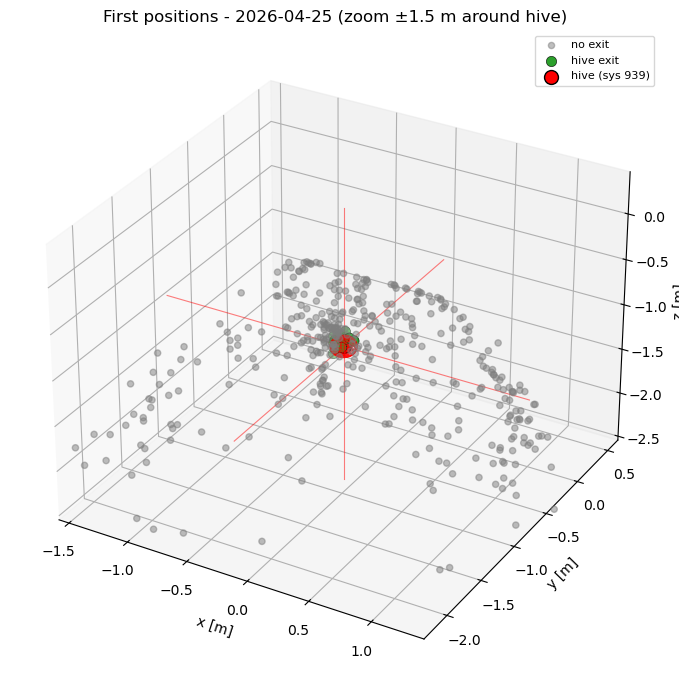

In [19]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

# Re-uses the same controls as the return plot.
ZOOM_RADIUS    = 1.5
OUTLIER_RADIUS = 5.0

if SPOT_SELECTION == "both":
    hives_to_show = [("hive (sys 900)", hive_900_pos),
                     ("hive (sys 939)", hive_939_pos)]
else:
    hives_to_show = [(f"hive (sys {SPOT_SELECTION})", HIVE_POS)]

hive_arr = np.stack([h for _, h in hives_to_show])

fig = plt.figure(figsize=(9, 7))
ax  = fig.add_subplot(111, projection="3d")

if not exit_results.empty:
    res = exit_results.dropna(subset=["first_x", "first_y", "first_z"]).copy()
    pts = res[["first_x", "first_y", "first_z"]].to_numpy(dtype=float)
    if len(pts):
        d2 = np.min(np.linalg.norm(
            pts[:, None, :] - hive_arr[None, :, :], axis=-1), axis=1)
        res = res[d2 <= OUTLIER_RADIUS]

    n_dropped = len(exit_results) - len(res)
    if n_dropped:
        print(f"(plot) dropped {n_dropped} outlier first-position(s) "
              f"beyond {OUTLIER_RADIUS} m from any hive")

    exited     = res[res["hive_exit"]]
    not_exited = res[~res["hive_exit"]]
    ax.scatter(not_exited["first_x"], not_exited["first_y"], not_exited["first_z"],
               c="tab:gray", s=20, alpha=0.5, label="no exit")
    ax.scatter(exited["first_x"], exited["first_y"], exited["first_z"],
               c="tab:green", s=55, edgecolors="black", linewidths=0.4,
               label="hive exit")


def plot_hive(ax, pos, tol, label, xlim, ylim, zlim):
    ax.plot(xlim, [pos[1]] * 2, [pos[2]] * 2, c="red", lw=0.8, alpha=0.5)
    ax.plot([pos[0]] * 2, ylim, [pos[2]] * 2, c="red", lw=0.8, alpha=0.5)
    ax.plot([pos[0]] * 2, [pos[1]] * 2, zlim, c="red", lw=0.8, alpha=0.5)
    u = np.linspace(0, 2 * np.pi, 20)
    v = np.linspace(0, np.pi, 12)
    xs = pos[0] + tol * np.outer(np.cos(u), np.sin(v))
    ys = pos[1] + tol * np.outer(np.sin(u), np.sin(v))
    zs = pos[2] + tol * np.outer(np.ones_like(u), np.cos(v))
    ax.plot_wireframe(xs, ys, zs, color="red", alpha=0.6, linewidth=0.7)
    ax.scatter(pos[0], pos[1], pos[2], c="red", marker="o",
               s=100, edgecolors="black", linewidths=1.0, label=label,
               depthshade=False)


xlim = (hive_arr[:, 0].min() - ZOOM_RADIUS, hive_arr[:, 0].max() + ZOOM_RADIUS)
ylim = (hive_arr[:, 1].min() - ZOOM_RADIUS, hive_arr[:, 1].max() + ZOOM_RADIUS)
zlim = (hive_arr[:, 2].min() - ZOOM_RADIUS, hive_arr[:, 2].max() + ZOOM_RADIUS)
ax.set_xlim(xlim)
ax.set_ylim(ylim)
ax.set_zlim(zlim)

for label, pos in hives_to_show:
    plot_hive(ax, pos, TOL, label, xlim, ylim, zlim)

ax.set_xlabel("x [m]")
ax.set_ylabel("y [m]")
ax.set_zlabel("z [m]")
ax.set_title(f"First positions - {TARGET_DATE.date()} "
             f"(zoom ±{ZOOM_RADIUS} m around hive)")
ax.legend(loc="best", fontsize=8)
plt.tight_layout()
plt.show()


#### 6.1 Sub indicators hive exit/entry

In this paragraph the sub indicators such as re_ratio, exit_return_count, trip_duration, daily_curve will be generated. Based on the values found in chapter 3 and 6.

exit_return_count  : exits=96  returns=139  (tracks=846)
re_ratio           : 1.448
trip_duration      : 96 matched  (unmatched exits=0, unmatched returns=43)
                   : median=2119.0s  mean=1752.9s  p95=2968.2s  max=4652.0s


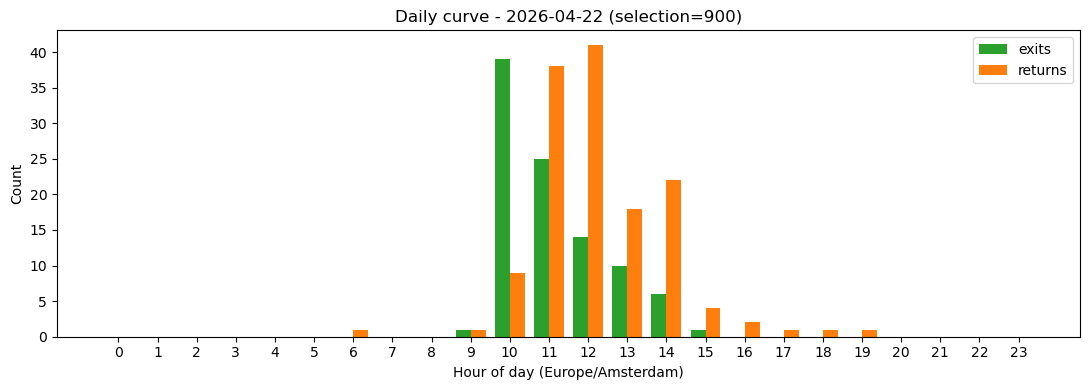

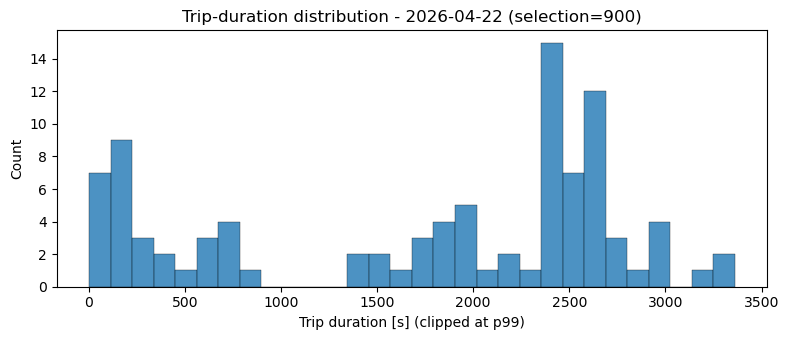

In [24]:
import matplotlib.pyplot as plt

# --- Assemble one table: one row per uid with timestamp + both labels ------
_meta = detections[["uid", "datetime", "start_datetime", "system_id"]].copy()
_meta["ts"] = pd.to_datetime(_meta["datetime"],
                             format="%Y%m%d_%H%M%S", errors="coerce")

_ret_flag  = results[["uid", "hive_return"]]
_ext_flag  = exit_results[["uid", "hive_exit"]]

events = (_meta.merge(_ret_flag, on="uid", how="left")
               .merge(_ext_flag, on="uid", how="left"))

# -------------------------------------------------------------------------
# 1. exit_return_count
# -------------------------------------------------------------------------
n_exits   = int(events["hive_exit"].fillna(False).sum())
n_returns = int(events["hive_return"].fillna(False).sum())
print(f"exit_return_count  : exits={n_exits}  returns={n_returns}"
      f"  (tracks={len(events)})")

# -------------------------------------------------------------------------
# 2. re_ratio = returns / exits
# -------------------------------------------------------------------------
re_ratio = (n_returns / n_exits) if n_exits > 0 else float("nan")
print(f"re_ratio           : {re_ratio:.3f}")

# -------------------------------------------------------------------------
# 3. trip_duration  (match every exit to the next unused return on the
#    same camera)
# -------------------------------------------------------------------------
_exits_df  = events[events["hive_exit"]   == True].sort_values("ts")
_returns_df = events[events["hive_return"] == True].sort_values("ts")

trip_rows = []
for sys_id in sorted(events["system_id"].dropna().unique()):
    g_ex = _exits_df[_exits_df["system_id"]  == sys_id]
    g_rt = _returns_df[_returns_df["system_id"] == sys_id].copy()
    used = set()
    for _, ex in g_ex.iterrows():
        cand = g_rt[(g_rt["ts"] > ex["ts"]) & (~g_rt["uid"].isin(used))]
        if cand.empty:
            continue
        rt = cand.iloc[0]
        trip_rows.append({
            "system_id"    : int(sys_id),
            "exit_uid"     : int(ex["uid"]),
            "return_uid"   : int(rt["uid"]),
            "exit_ts"      : ex["ts"],
            "return_ts"    : rt["ts"],
            "trip_seconds" : (rt["ts"] - ex["ts"]).total_seconds(),
        })
        used.add(rt["uid"])

trips = pd.DataFrame(trip_rows)
n_unmatched_exits   = n_exits   - len(trips)
n_unmatched_returns = n_returns - len(trips)

print(f"trip_duration      : {len(trips)} matched  "
      f"(unmatched exits={n_unmatched_exits}, "
      f"unmatched returns={n_unmatched_returns})")
if not trips.empty:
    s = trips["trip_seconds"]
    print(f"                   : median={s.median():.1f}s  "
          f"mean={s.mean():.1f}s  p95={s.quantile(0.95):.1f}s  "
          f"max={s.max():.1f}s")

# -------------------------------------------------------------------------
# 4. daily_curve (per-hour counts, local time)
# -------------------------------------------------------------------------
events["hour"] = events["ts"].dt.hour
hours = list(range(24))

exits_by_h   = (events[events["hive_exit"]   == True]
                .groupby("hour").size().reindex(hours, fill_value=0))
returns_by_h = (events[events["hive_return"] == True]
                .groupby("hour").size().reindex(hours, fill_value=0))

daily_curve = pd.DataFrame({"exits": exits_by_h, "returns": returns_by_h})

# -------------------------------------------------------------------------
# Plot: daily curve
# -------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(11, 4))
x = np.arange(24)
w = 0.38
ax.bar(x - w/2, daily_curve["exits"].values,   width=w,
       label="exits",   color="tab:green")
ax.bar(x + w/2, daily_curve["returns"].values, width=w,
       label="returns", color="tab:orange")
ax.set_xticks(x)
ax.set_xlabel("Hour of day (Europe/Amsterdam)")
ax.set_ylabel("Count")
ax.set_title(f"Daily curve - {TARGET_DATE.date()} "
             f"(selection={SPOT_SELECTION})")
ax.legend()
plt.tight_layout()
plt.show()

# -------------------------------------------------------------------------
# Optional: plot trip-duration histogram (only if we have matched trips)
# -------------------------------------------------------------------------
if not trips.empty:
    fig, ax = plt.subplots(figsize=(8, 3.5))
    ax.hist(trips["trip_seconds"].clip(upper=trips["trip_seconds"].quantile(0.99)),
            bins=30, color="tab:blue", alpha=0.8, edgecolor="black", linewidth=0.3)
    ax.set_xlabel("Trip duration [s] (clipped at p99)")
    ax.set_ylabel("Count")
    ax.set_title(f"Trip-duration distribution - {TARGET_DATE.date()} (selection={SPOT_SELECTION})")
    plt.tight_layout()
    plt.show()


#### Sanity check: show 20 hive exits

Prints the top 20 tracks flagged as a hive exit (closest first-sample to the hive, so the "best" candidates) with their datetime, trajectory distance and mean velocity. Paste any datetime into the PATS web interface to look up the video.


In [112]:
N = 20

# Join exit_results with the detection metadata to get datetime / dist_traject / vel_mean.
_exits = exit_results[exit_results["hive_exit"]].copy()

_cols_from_det = ["uid", "datetime", "start_datetime", "dist_traject", "vel_mean","size"]
_have = [c for c in _cols_from_det if c in detections.columns]
_det  = detections[_have].drop_duplicates("uid")

_sample = (_exits.merge(_det, on="uid", how="left")
                 .sort_values("min_dist_start")
                 .head(N))

show_cols = [c for c in
             ["uid", "datetime", "system_id", "min_dist_start",
              "dist_traject", "vel_mean", "size"]
             if c in _sample.columns]

_sample["size"] = _sample["size"]*1000

_sample = _sample[show_cols].rename(columns={
    "min_dist_start": "dist_to_hive_start [m]",
    "dist_traject"  : "dist_trajectory [m]",
    "vel_mean"      : "vel_mean [m/s]",
    "size"          : "size [mm]",
})


print(f"Top {len(_sample)} hive exits on {TARGET_DATE.date()} "
      f"(closest first-sample to hive first):\n")
print(_sample.to_string(index=False))


Top 20 hive exits on 2026-04-19 (closest first-sample to hive first):

    uid        datetime  system_id  dist_to_hive_start [m]  dist_trajectory [m]  vel_mean [m/s]  size [mm]
1329273 20260419_114022        900                0.008408             1.024797        0.570700  10.885323
1335506 20260419_141201        900                0.008793             0.990629        0.427421  10.329262
1335803 20260419_141954        900                0.011191             2.438987        0.273285   9.218192
1333595 20260419_132206        900                0.011776             1.877744        1.294995  11.733060
1331957 20260419_124041        900                0.013428             3.797602        0.364036   9.353968
1332513 20260419_124959        900                0.015405             1.374035        0.673595   9.744206
1335087 20260419_135308        900                0.016930             1.420112        1.031227  12.083083
1330545 20260419_121410        900                0.018288             0.

### 7. Full-track sanity check

Load `flight_tracks.csv` (the one exported in section 5) and draw N random flights as 3D lines, each with:
- green ● at the start (first valid sample)
- orange ● at the end (last valid sample)
- hive + TOL sphere in red

Flip `TRACK_SET` between `"exits"`, `"returns"`, or `"all"` to restrict the sample. Flip `RANDOM` off to get the top-N closest-to-hive candidates instead of a uniform sample.


Plotting 20 exits track(s) (RANDOM=True)


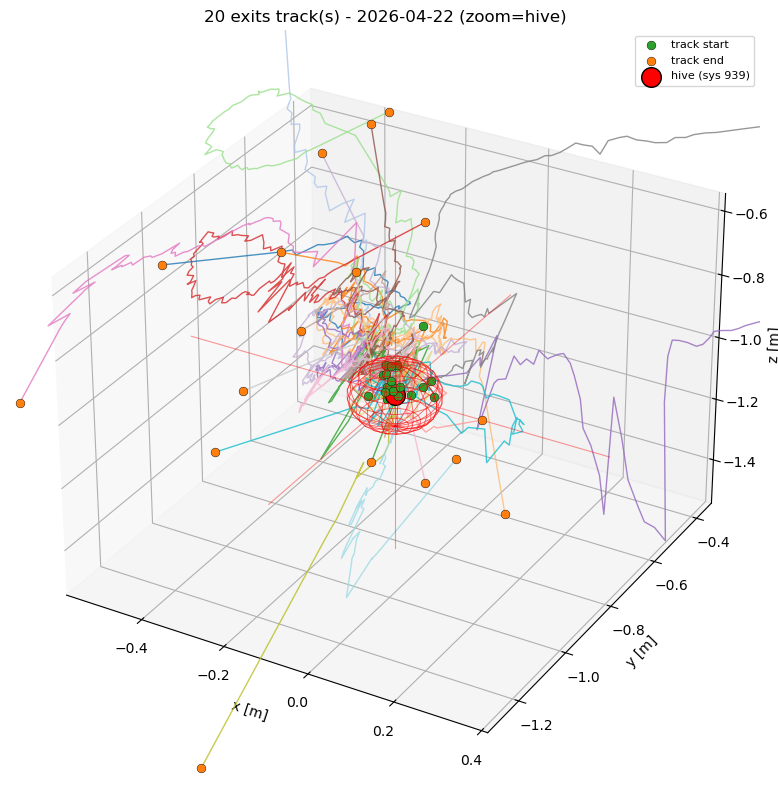

In [94]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

# -- Controls ---------------------------------------------------------------
N            = 20
TRACK_SET    = "exits"     # "exits" | "returns" | "all"
RANDOM       = True        # False = take the best (lowest min-distance) ones
RANDOM_SEED  = 0

# Zoom mode:
#   "auto"   -> fit axes to the actual plotted tracks (+ PADDING)
#   "hive"   -> ZOOM_RADIUS box around the hive(s)
ZOOM_MODE    = "hive"
PADDING      = 0.05        # metres of slack around the track bounding box
ZOOM_RADIUS  = 0.5         # used only when ZOOM_MODE == "hive"

# Safety clip: ignore samples further than this from the hive when
# auto-fitting, so one glitchy point doesn't ruin the view.
CLIP_RADIUS  = 3.0
# ---------------------------------------------------------------------------

# 1. Load the exported flight tracks.
tracks_csv = EXPORT_DIR / "flight_tracks.csv"
if not tracks_csv.exists():
    raise FileNotFoundError(
        f"{tracks_csv} not found - run the export cell first."
    )
ft = pd.read_csv(tracks_csv)
if "pos_valid_insect" in ft.columns:
    ft = ft[ft["pos_valid_insect"] == 1]

# 2. Pick which uids to plot.
if TRACK_SET == "exits":
    pool = exit_results[exit_results["hive_exit"]].copy()
    score_col = "min_dist_start"
elif TRACK_SET == "returns":
    pool = results[results["hive_return"]].copy()
    score_col = "min_dist_hive"
elif TRACK_SET == "all":
    pool = results.copy()
    score_col = "min_dist_hive"
else:
    raise ValueError(f"Unknown TRACK_SET={TRACK_SET!r}")

if pool.empty:
    raise RuntimeError(f"No tracks in pool (TRACK_SET={TRACK_SET!r}).")

if RANDOM:
    sample = pool.sample(n=min(N, len(pool)), random_state=RANDOM_SEED)
else:
    sample = pool.sort_values(score_col).head(N)

uids = sample["uid"].astype(int).tolist()
print(f"Plotting {len(uids)} {TRACK_SET} track(s) (RANDOM={RANDOM})")

# 3. Which hives to draw.
if SPOT_SELECTION == "both":
    hives_to_show = [("hive (sys 900)", hive_900_pos),
                     ("hive (sys 939)", hive_939_pos)]
else:
    hives_to_show = [(f"hive (sys {SPOT_SELECTION})", HIVE_POS)]
hive_arr = np.stack([h for _, h in hives_to_show])

# 4. Plot.
fig = plt.figure(figsize=(10, 8))
ax  = fig.add_subplot(111, projection="3d")

cmap = plt.get_cmap("tab20")
lines_added = 0
plotted_points = []            # collect xyz of everything actually drawn

for idx, uid in enumerate(uids):
    trk = ft[ft["detection_uid"] == uid]
    if trk.empty:
        print(f"  uid={uid}: no rows in flight_tracks.csv - skipped")
        continue
    x = trk["posX_insect"].to_numpy(dtype=float)
    y = trk["posY_insect"].to_numpy(dtype=float)
    z = trk["posZ_insect"].to_numpy(dtype=float)

    # For auto-fitting: drop samples far from any hive so one glitch point
    # doesn't stretch the box to infinity.
    pts = np.stack([x, y, z], axis=1)
    dists = np.min(np.linalg.norm(
        pts[:, None, :] - hive_arr[None, :, :], axis=-1), axis=1)
    keep = dists <= CLIP_RADIUS
    plotted_points.append(pts[keep])

    color = cmap(idx % 20)
    ax.plot(x, y, z, color=color, lw=1.0, alpha=0.8)
    ax.scatter(x[0],  y[0],  z[0],  color="tab:green",  s=40,
               edgecolors="black", linewidths=0.3,
               label="track start" if lines_added == 0 else None)
    ax.scatter(x[-1], y[-1], z[-1], color="tab:orange", s=40,
               edgecolors="black", linewidths=0.3,
               label="track end" if lines_added == 0 else None)
    lines_added += 1

# 5. Decide axis limits.
if ZOOM_MODE == "hive":
    xlim = (hive_arr[:, 0].min() - ZOOM_RADIUS, hive_arr[:, 0].max() + ZOOM_RADIUS)
    ylim = (hive_arr[:, 1].min() - ZOOM_RADIUS, hive_arr[:, 1].max() + ZOOM_RADIUS)
    zlim = (hive_arr[:, 2].min() - ZOOM_RADIUS, hive_arr[:, 2].max() + ZOOM_RADIUS)
else:  # "auto"
    all_pts = np.concatenate(plotted_points) if plotted_points else hive_arr
    all_pts = np.vstack([all_pts, hive_arr])    # always include hive(s)
    lo = all_pts.min(axis=0) - PADDING
    hi = all_pts.max(axis=0) + PADDING
    xlim = (lo[0], hi[0]); ylim = (lo[1], hi[1]); zlim = (lo[2], hi[2])

ax.set_xlim(xlim); ax.set_ylim(ylim); ax.set_zlim(zlim)

# 6. Draw hive(s) on top.
def _plot_hive(ax, pos, tol, label, xlim, ylim, zlim):
    ax.plot(xlim, [pos[1]] * 2, [pos[2]] * 2, c="red", lw=0.8, alpha=0.4)
    ax.plot([pos[0]] * 2, ylim, [pos[2]] * 2, c="red", lw=0.8, alpha=0.4)
    ax.plot([pos[0]] * 2, [pos[1]] * 2, zlim, c="red", lw=0.8, alpha=0.4)
    u = np.linspace(0, 2 * np.pi, 20); v = np.linspace(0, np.pi, 12)
    xs = pos[0] + tol * np.outer(np.cos(u), np.sin(v))
    ys = pos[1] + tol * np.outer(np.sin(u), np.sin(v))
    zs = pos[2] + tol * np.outer(np.ones_like(u), np.cos(v))
    ax.plot_wireframe(xs, ys, zs, color="red", alpha=0.6, linewidth=0.6)
    ax.scatter(pos[0], pos[1], pos[2], c="red", marker="o",
               s=200, edgecolors="black", linewidths=1.0, label=label,
               depthshade=False)

for lbl, pos in hives_to_show:
    _plot_hive(ax, pos, TOL, lbl, xlim, ylim, zlim)

ax.set_xlabel("x [m]"); ax.set_ylabel("y [m]"); ax.set_zlabel("z [m]")
ax.set_title(f"{len(uids)} {TRACK_SET} track(s) - {TARGET_DATE.date()} "
             f"(zoom={ZOOM_MODE})")
ax.legend(loc="best", fontsize=8)
plt.tight_layout()
plt.show()


In [ ]:
### 7b. Multi-day random sampler: 10 return / 10 exit / 10 other (x4 graphs)
# Pull tracks from EVERY cached `flight_data_<date>_system_<id>` folder, classify
# each as return / exit / other (using the same v1 logic as section 7), then plot
# 4 independent random samples side-by-side. Each sample contains:
#   - 10 hive returns           (blue lines)
#   - 10 hive exits             (orange lines)
#   - 10 "other" tracks         (gray lines  -> neither a return nor an exit)
# Start of every track is marked green, end is marked red. Hive(s) + TOL sphere
# drawn in red. Reuses HIVE_BY_SYSTEM / TOL from earlier cells.

import re
import random
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401  (registers 3d projection)

# -- Controls ---------------------------------------------------------------
N_RETURN     = 10
N_EXIT       = 10
N_OTHER      = 10
N_GRAPHS     = 4            # 2 x 2 grid
RANDOM_SEED  = 0            # base seed; each subplot uses SEED + i

TAIL_FRAMES  = 10           # mirrors section 3's return classifier
ZOOM_RADIUS  = 0.7          # metres around hive(s)
# ---------------------------------------------------------------------------

# 1. Find the cache root (same logic as section 14).
CACHE_BASE = Path("cache")
if not CACHE_BASE.exists():
    CACHE_BASE = EXPORT_DIR.parent
print(f"Sweeping cache: {CACHE_BASE.resolve()}")

pat = re.compile(r"flight_data_(\d{4}-\d{2}-\d{2})_system_(\d+)$")

# 2. Classify every track on disk into one of {return, exit, other}.
#    Store only the file path so we can re-read the full xyz lazily for the
#    handful (~120) of tracks we actually plot.
pool_return, pool_exit, pool_other = [], [], []

for d in sorted(CACHE_BASE.glob("flight_data_*_system_*")):
    m = pat.match(d.name)
    if not m:
        continue
    date_str, sys_str = m.groups()
    sys_id = int(sys_str)
    if sys_id not in HIVE_BY_SYSTEM:
        continue
    det_csv    = d / "detections.csv"
    tracks_dir = d / "tracks"
    if not det_csv.exists() or not tracks_dir.exists():
        continue

    hive = np.asarray(HIVE_BY_SYSTEM[sys_id], dtype=float)
    dets = pd.read_csv(det_csv)

    for _, det in dets.iterrows():
        uid = int(det["uid"])
        trk_path = tracks_dir / f"{uid}.csv"
        if not trk_path.exists():
            continue
        trk = pd.read_csv(trk_path)
        if "pos_valid_insect" in trk.columns:
            trk = trk[trk["pos_valid_insect"] == 1]
        if len(trk) == 0:
            continue
        xyz = trk[["posX_insect", "posY_insect", "posZ_insect"]].to_numpy(dtype=float)

        # Return: min distance over the last TAIL_FRAMES valid samples <= TOL.
        tail_xyz = xyz[-TAIL_FRAMES:]
        d_ret = float(np.min(np.linalg.norm(tail_xyz - hive, axis=1)))
        is_ret = d_ret <= TOL

        # Exit (v1, simple): first valid sample <= TOL.
        d_exit = float(np.linalg.norm(xyz[0] - hive))
        is_exit = d_exit <= TOL

        rec = (date_str, sys_id, uid, hive, trk_path)
        if is_ret and not is_exit:
            pool_return.append(rec)
        elif is_exit and not is_ret:
            pool_exit.append(rec)
        elif not is_ret and not is_exit:
            pool_other.append(rec)
        # tracks that look like both are skipped here (rare; classifier overlap)

print(f"Pool sizes across all days:  returns={len(pool_return)}  "
      f"exits={len(pool_exit)}  other={len(pool_other)}")
if not (pool_return and pool_exit and pool_other):
    raise RuntimeError("Need at least one track in every category - check cache.")

# 3. Build the 2x2 figure.
fig = plt.figure(figsize=(18, 14))

def _draw_hive(ax, pos, tol):
    u = np.linspace(0, 2 * np.pi, 20)
    v = np.linspace(0, np.pi, 12)
    xs = pos[0] + tol * np.outer(np.cos(u), np.sin(v))
    ys = pos[1] + tol * np.outer(np.sin(u), np.sin(v))
    zs = pos[2] + tol * np.outer(np.ones_like(u), np.cos(v))
    ax.plot_wireframe(xs, ys, zs, color="red", alpha=0.5, linewidth=0.5)
    ax.scatter(pos[0], pos[1], pos[2], c="red", marker="o", s=120,
               edgecolors="black", linewidths=1.0, depthshade=False)

def _plot_track(ax, trk_path, color, label):
    trk = pd.read_csv(trk_path)
    if "pos_valid_insect" in trk.columns:
        trk = trk[trk["pos_valid_insect"] == 1]
    if len(trk) == 0:
        return
    x = trk["posX_insect"].to_numpy(dtype=float)
    y = trk["posY_insect"].to_numpy(dtype=float)
    z = trk["posZ_insect"].to_numpy(dtype=float)
    ax.plot(x, y, z, color=color, lw=1.0, alpha=0.75, label=label)
    ax.scatter(x[0],  y[0],  z[0],  color="tab:green",  s=20,
               edgecolors="black", linewidths=0.3)
    ax.scatter(x[-1], y[-1], z[-1], color="tab:red",    s=20,
               edgecolors="black", linewidths=0.3)

for g in range(N_GRAPHS):
    rng = random.Random(RANDOM_SEED + g)
    sample_ret   = rng.sample(pool_return, k=min(N_RETURN, len(pool_return)))
    sample_exit  = rng.sample(pool_exit,   k=min(N_EXIT,   len(pool_exit)))
    sample_other = rng.sample(pool_other,  k=min(N_OTHER,  len(pool_other)))

    ax = fig.add_subplot(2, 2, g + 1, projection="3d")
    hives_in_view = []

    for i, rec in enumerate(sample_ret):
        _plot_track(ax, rec[4], "tab:blue", "return" if i == 0 else None)
        hives_in_view.append(rec[3])
    for i, rec in enumerate(sample_exit):
        _plot_track(ax, rec[4], "tab:orange", "exit" if i == 0 else None)
        hives_in_view.append(rec[3])
    for i, rec in enumerate(sample_other):
        _plot_track(ax, rec[4], "tab:gray", "other" if i == 0 else None)
        hives_in_view.append(rec[3])

    hive_arr = np.unique(np.vstack(hives_in_view), axis=0)
    xlim = (hive_arr[:, 0].min() - ZOOM_RADIUS, hive_arr[:, 0].max() + ZOOM_RADIUS)
    ylim = (hive_arr[:, 1].min() - ZOOM_RADIUS, hive_arr[:, 1].max() + ZOOM_RADIUS)
    zlim = (hive_arr[:, 2].min() - ZOOM_RADIUS, hive_arr[:, 2].max() + ZOOM_RADIUS)
    ax.set_xlim(xlim); ax.set_ylim(ylim); ax.set_zlim(zlim)

    for hive in hive_arr:
        _draw_hive(ax, hive, TOL)

    ax.set_xlabel("x [m]"); ax.set_ylabel("y [m]"); ax.set_zlabel("z [m]")
    ax.set_title(f"Sample {g + 1}  -  {N_RETURN} return / {N_EXIT} exit / "
                 f"{N_OTHER} other  (seed={RANDOM_SEED + g})")
    ax.legend(loc="upper right", fontsize=8)

fig.suptitle("Multi-day random track sampler (returns / exits / other)",
             y=1.00, fontsize=13)
plt.tight_layout()
plt.show()


### Diagnostic: where do my detections actually fall?

Notebook count vs. web-UI count disagreeing is almost always a timezone mismatch. This cell:

1. Counts `detections` by their **local-date prefix** (from the `datetime` column, which PATS returns in Europe/Amsterdam local time).
2. Also counts by **UTC date** (parsed from `start_datetime`, which is GMT).
3. Prints the earliest and latest detection in each.

If the local-date column says "April 22: 387, April 21: 272" when `TARGET_DATE = 2026-04-22`, your query window is leaking into April 21 and the fix is to shift the `day_start` / `day_end` by the Amsterdam UTC offset (+2 h in April).


In [32]:
import pandas as pd

print(f"TARGET_DATE   = {TARGET_DATE.date()}")
print(f"Total rows    = {len(detections)}")
print()

# 1. Local-date distribution (what the PATS web UI groups by).
local_date = detections["datetime"].astype(str).str[:8]           # YYYYMMDD
print("By LOCAL date (Europe/Amsterdam, from `datetime` column):")
print(local_date.value_counts().sort_index().to_string())
print()

# 2. UTC-date distribution (what the server likely groups by internally).
utc_dt = pd.to_datetime(detections["start_datetime"], errors="coerce", utc=True)
utc_date = utc_dt.dt.strftime("%Y%m%d")
print("By UTC date (from `start_datetime`):")
print(utc_date.value_counts().sort_index().to_string())
print()

# 3. Earliest / latest in each frame of reference.
print("Earliest / latest `datetime`      (local):",
      detections["datetime"].min(), "->", detections["datetime"].max())
print("Earliest / latest `start_datetime`(UTC)  :",
      utc_dt.min(), "->", utc_dt.max())


TARGET_DATE   = 2026-04-21
Total rows    = 603

By LOCAL date (Europe/Amsterdam, from `datetime` column):
datetime
20260421    603

By UTC date (from `start_datetime`):
start_datetime
20260421    603

Earliest / latest `datetime`      (local): 20260421_071942 -> 20260421_185228
Earliest / latest `start_datetime`(UTC)  : 2026-04-21 05:19:42+00:00 -> 2026-04-21 16:52:28+00:00


### 8. Hive-position calibration

Sanity check on `hive_900_pos` / `hive_939_pos`: take the last valid XYZ of every track (and optionally the first, since exits depart from the hive too), bin into small 3D cubes, and take the most-populated cube. Works per `system_id` because each camera has its own coordinate frame.

- **BUCKET** - cube size in metres. 5 cm is a good default.
- **USE_FIRST** - include first valid XYZ of each track as well as the last. Doubles the support.
- **TOP_K** - how many top buckets to print.
- **REFINE_RADIUS** - weighted centroid is computed over all points within this radius of the winning bucket centre, for sub-bucket precision.

The printed "refined centroid" is the empirical hive position. Compare to the configured `hive_900_pos` / `hive_939_pos` - the delta tells you how far off your manual calibration is.



=== system_id=939  (n samples = 844) ===
configured  hive_939_pos = (-0.086, -0.828, -1.045)
top 5 buckets (centre x, y, z  -  count):
  (-0.150, -0.800, -1.000)   6
  (-0.150, -0.750, -0.950)   4
  (+1.100, -0.500, -1.300)   3
  (-0.150, -0.800, -1.100)   3
  (-0.150, -0.800, -1.050)   3
refined centroid (n=38 within 10 cm): (-0.154, -0.783, -1.003)
delta vs configured: (-0.068, +0.045, +0.042)  |9.2 cm|


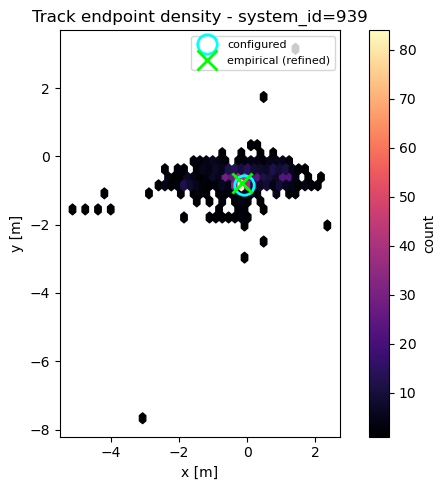

In [20]:
from collections import Counter
import matplotlib.pyplot as plt

# -- Controls ---------------------------------------------------------------
BUCKET         = 0.05   # 5 cm grid
USE_FIRST      = True   # include first valid XYZ too (exits start at hive)
TOP_K          = 5
REFINE_RADIUS  = 0.10   # 10 cm
# ---------------------------------------------------------------------------

# 1. Load tracks.
ft = pd.read_csv(EXPORT_DIR / "flight_tracks.csv")
if "pos_valid_insect" in ft.columns:
    ft = ft[ft["pos_valid_insect"] == 1]

# 2. Make sure we have a system_id column. flight_tracks.csv already has one;
#    fall back to detections if needed.
if "system_id" not in ft.columns:
    _sys = detections[["uid", "system_id"]].drop_duplicates("uid")
    ft = ft.merge(_sys, left_on="detection_uid", right_on="uid", how="left")
ft = ft.dropna(subset=["system_id"])
ft["system_id"] = ft["system_id"].astype(int)

# 3. Sort so .head(1) / .tail(1) is temporally meaningful.
sort_cols = ["detection_uid"]
for cand in ("rs_id", "time_insect", "timestamp"):
    if cand in ft.columns:
        sort_cols.append(cand)
        break
ft = ft.sort_values(sort_cols)

configured = {900: hive_900_pos, 939: hive_939_pos}

for sys_id, g in ft.groupby("system_id"):
    g_uid = g.groupby("detection_uid")
    last  = g_uid.tail(1)
    pts   = last[["posX_insect", "posY_insect", "posZ_insect"]].to_numpy()
    if USE_FIRST:
        first = g_uid.head(1)
        pts = np.vstack([
            pts,
            first[["posX_insect", "posY_insect", "posZ_insect"]].to_numpy(),
        ])

    # 4. Bucket into the 3D grid.
    buckets = np.round(pts / BUCKET).astype(int)
    counter = Counter(map(tuple, buckets))
    top = counter.most_common(TOP_K)

    print(f"\n=== system_id={sys_id}  (n samples = {len(pts)}) ===")
    if int(sys_id) in configured:
        cfg = configured[int(sys_id)]
        print(f"configured  hive_{sys_id}_pos = "
              f"({cfg[0]:+.3f}, {cfg[1]:+.3f}, {cfg[2]:+.3f})")
    else:
        cfg = None
        print(f"(no configured hive for system_id={sys_id})")
    print(f"top {TOP_K} buckets (centre x, y, z  -  count):")
    for (bx, by, bz), n in top:
        cx, cy, cz = bx * BUCKET, by * BUCKET, bz * BUCKET
        print(f"  ({cx:+.3f}, {cy:+.3f}, {cz:+.3f})   {n}")

    # 5. Refined centroid within REFINE_RADIUS of the winner.
    bx, by, bz = top[0][0]
    winner = np.array([bx * BUCKET, by * BUCKET, bz * BUCKET])
    d = np.linalg.norm(pts - winner, axis=1)
    near = pts[d <= REFINE_RADIUS]
    centroid = near.mean(axis=0)
    print(f"refined centroid (n={len(near)} within {REFINE_RADIUS*100:.0f} cm): "
          f"({centroid[0]:+.3f}, {centroid[1]:+.3f}, {centroid[2]:+.3f})")

    if cfg is not None:
        delta = centroid - np.asarray(cfg)
        print(f"delta vs configured: "
              f"({delta[0]:+.3f}, {delta[1]:+.3f}, {delta[2]:+.3f})  "
              f"|{np.linalg.norm(delta)*100:.1f} cm|")

    # 6. Visual: top-down (x, y) heatmap of endpoints.
    fig, ax = plt.subplots(figsize=(6, 5))
    h = ax.hexbin(pts[:, 0], pts[:, 1], gridsize=40, cmap="magma", mincnt=1)
    if cfg is not None:
        ax.plot(cfg[0], cfg[1],
                "o", markersize=14, markerfacecolor="none",
                markeredgecolor="cyan", markeredgewidth=2, label="configured")
    ax.plot(centroid[0], centroid[1],
            "x", markersize=14, markeredgecolor="lime", markeredgewidth=2,
            label="empirical (refined)")
    ax.set_xlabel("x [m]"); ax.set_ylabel("y [m]")
    ax.set_aspect("equal")
    ax.set_title(f"Track endpoint density - system_id={sys_id}")
    ax.legend(loc="best", fontsize=8)
    fig.colorbar(h, ax=ax, label="count")
    plt.tight_layout()
    plt.show()


### 9. Flight geometry sub-indicators

Three geometry-derived features per track, aggregated over the day:

- **Path tortuosity** - `arc_length / end_to_end_displacement`. `1.0` = perfect straight line (directed transit); higher = winding (searching, hovering). Cleanest proxy for "foraging vs. transiting."
- **Exit heading** - in the top-down (x, y) plane, the vector from the hive to the first track sample `>= REF_DIST` m away. Converted to azimuth and shown as a rose plot per camera.
- **Return heading** - azimuth of the first valid sample of a return track (where the bee entered the frame), relative to the hive. Tells you which direction the bees are foraging *from*.

**Reference frame.** Both headings are rotated so that the hive entrance faces **0 degrees** and go clockwise like a compass (0 = straight out of the entrance; 90 = right of the entrance when you're inside the hive looking out; etc.). Each camera needs its entrance direction configured in `HIVE_ENTRANCE_AZIMUTH_BY_SYSTEM` below - the exit rose plot is the calibration tool: rotate the entrance-azimuth until the exit bulge sits at 0 degrees.


In [ ]:
import matplotlib.pyplot as plt

# -- Controls ---------------------------------------------------------------
REF_DIST   = 0.30   # m - for exit heading, first sample at least this far from hive
N_BINS     = 24     # rose plot bins (15 deg each)
TORT_CLIP  = 5.0    # tortuosity histogram x-axis clip

# Entrance direction per camera, in degrees CCW from the camera's +x axis.
# EDIT these after looking at the exit rose plot: rotate the value until the
# exit bulge sits at 0 degrees on the rose.
HIVE_ENTRANCE_AZIMUTH_BY_SYSTEM = {
    900: 0.0,
    939: 0.0,
}
# ---------------------------------------------------------------------------

# 1. Load tracks.
ft = pd.read_csv(EXPORT_DIR / "flight_tracks.csv")
if "pos_valid_insect" in ft.columns:
    ft = ft[ft["pos_valid_insect"] == 1]
sort_cols = ["detection_uid"]
for cand in ("rs_id", "time_insect", "timestamp"):
    if cand in ft.columns:
        sort_cols.append(cand); break
ft = ft.sort_values(sort_cols)

# Quick lookups for flags.
ret_flags = results.set_index("uid")["hive_return"]
ext_flags = exit_results.set_index("uid")["hive_exit"]

# 2. Per-track geometry + headings in one pass.
tort_rows       = []
exit_headings   = []   # list of (sys_id, azimuth_rad_entrance_relative)
return_headings = []

for uid, trk in ft.groupby("detection_uid"):
    xyz = trk[["posX_insect", "posY_insect", "posZ_insect"]].to_numpy(float)
    if len(xyz) < 2:
        continue
    if "system_id" not in trk.columns:
        continue
    sys_id = int(trk["system_id"].iloc[0])
    if sys_id not in HIVE_BY_SYSTEM:
        continue
    hive = np.asarray(HIVE_BY_SYSTEM[sys_id])
    entrance_az = HIVE_ENTRANCE_AZIMUTH_BY_SYSTEM.get(sys_id, 0.0)

    # Tortuosity.
    arc  = float(np.linalg.norm(np.diff(xyz, axis=0), axis=1).sum())
    disp = float(np.linalg.norm(xyz[-1] - xyz[0]))
    tort = arc / disp if disp > 1e-6 else np.nan

    is_exit   = bool(ext_flags.get(int(uid), False))
    is_return = bool(ret_flags.get(int(uid), False))

    tort_rows.append({"uid": int(uid), "system_id": sys_id,
                      "arc_m": arc, "displacement_m": disp, "tortuosity": tort,
                      "hive_exit": is_exit, "hive_return": is_return})

    # Exit heading: first sample in the (x, y) plane at >= REF_DIST from hive.
    if is_exit:
        dists_xy = np.linalg.norm(xyz[:, :2] - hive[:2], axis=1)
        idx = np.where(dists_xy >= REF_DIST)[0]
        if len(idx):
            p_xy = xyz[idx[0], :2]
            az = np.arctan2(p_xy[1] - hive[1], p_xy[0] - hive[0])
            az = (az - np.deg2rad(entrance_az)) % (2 * np.pi)
            exit_headings.append((sys_id, az))

    # Return heading: first valid sample of the track (where bee entered frame).
    if is_return:
        p_xy = xyz[0, :2]
        az = np.arctan2(p_xy[1] - hive[1], p_xy[0] - hive[0])
        az = (az - np.deg2rad(entrance_az)) % (2 * np.pi)
        return_headings.append((sys_id, az))

tort_df = pd.DataFrame(tort_rows)

print(f"tracks analysed : {len(tort_df)}")
print(f"exit headings   : {len(exit_headings)}")
print(f"return headings : {len(return_headings)}")
if not tort_df.empty:
    for mask, label in [(tort_df["hive_exit"],   "exits  "),
                        (tort_df["hive_return"], "returns"),
                        (slice(None),            "all    ")]:
        vals = tort_df.loc[mask, "tortuosity"].dropna()
        if not len(vals):
            continue
        print(f"tortuosity {label} : n={len(vals):4d}  "
              f"median={vals.median():5.2f}  "
              f"p75={vals.quantile(0.75):5.2f}  "
              f"p95={vals.quantile(0.95):5.2f}")

# 3. Tortuosity histogram (exits + returns overlaid).
fig, ax = plt.subplots(figsize=(9, 4))
bins = np.linspace(1.0, TORT_CLIP, 41)
for label, mask, color in [
    ("exits",   tort_df["hive_exit"],    "tab:green"),
    ("returns", tort_df["hive_return"],  "tab:orange"),
]:
    vals = tort_df.loc[mask, "tortuosity"].dropna().clip(upper=TORT_CLIP)
    if vals.empty:
        continue
    ax.hist(vals, bins=bins, alpha=0.55, color=color,
            label=f"{label} (n={len(vals)}, median={vals.median():.2f})",
            edgecolor="black", linewidth=0.3)
ax.axvline(1.0, color="black", ls="--", alpha=0.5,
           label="straight line")
ax.set_xlabel("Path tortuosity  (arc length / straight-line displacement)")
ax.set_ylabel("Count")
ax.set_title(f"Path tortuosity - {TARGET_DATE.date()} "
             f"(selection={SPOT_SELECTION})")
ax.legend()
plt.tight_layout()
plt.show()

# 4. Rose plots per system_id.
def _rose(ax, angles_rad, title, color):
    if len(angles_rad) == 0:
        ax.set_title(f"{title}\n(no data)")
        return
    bins_theta = np.linspace(0, 2 * np.pi, N_BINS + 1)
    hist, _ = np.histogram(angles_rad, bins=bins_theta)
    width = 2 * np.pi / N_BINS
    ax.bar(bins_theta[:-1], hist, width=width, bottom=0.0,
           align="edge", color=color, alpha=0.85,
           edgecolor="black", linewidth=0.3)
    # compass layout: 0 deg at top, clockwise
    ax.set_theta_zero_location("N")
    ax.set_theta_direction(-1)
    ax.set_xticks(np.deg2rad([0, 45, 90, 135, 180, 225, 270, 315]))
    ax.set_xticklabels(["entrance 0\u00b0", "45", "90 (right)", "135",
                         "180 (behind)", "225", "270 (left)", "315"])
    ax.set_title(f"{title} (n={len(angles_rad)})")

systems_present = sorted(set(
    [s for s, _ in exit_headings] + [s for s, _ in return_headings]
))
for sys_id in systems_present:
    ex = np.array([a for s, a in exit_headings   if s == sys_id])
    rt = np.array([a for s, a in return_headings if s == sys_id])

    fig, axes = plt.subplots(1, 2, figsize=(12, 5.5),
                             subplot_kw=dict(projection="polar"))
    _rose(axes[0], ex, f"Exit headings - system {sys_id}",   "tab:green")
    _rose(axes[1], rt, f"Return headings - system {sys_id}", "tab:orange")
    fig.suptitle(f"{TARGET_DATE.date()}  entrance_az="
                 f"{HIVE_ENTRANCE_AZIMUTH_BY_SYSTEM.get(sys_id, 0.0):.1f}\u00b0",
                 y=1.02)
    plt.tight_layout()
    plt.show()


### 10. TOL threshold diagnostic

Histogram + CDF of the two distances that drive classification:
- **`min_dist_hive`** from `results` - closest the track ever got to the hive during its tail frames. Drives `hive_return`.
- **`min_dist_start`** from `exit_results` - distance of the first valid sample from the hive. Drives `hive_exit`.

**What to look for.** If the distribution has a sharp spike near zero (real events) with a long flat tail (fly-bys) and a clear valley between them, pick TOL at the valley - that's a principled threshold. If it decays monotonically with no valley, min-distance alone can't separate events from fly-bys and we need a second feature (e.g. inward-velocity direction at track end).

The CDF on the right-hand y-axis lets you read off "if TOL=X, I catch Y% of tracks" directly.


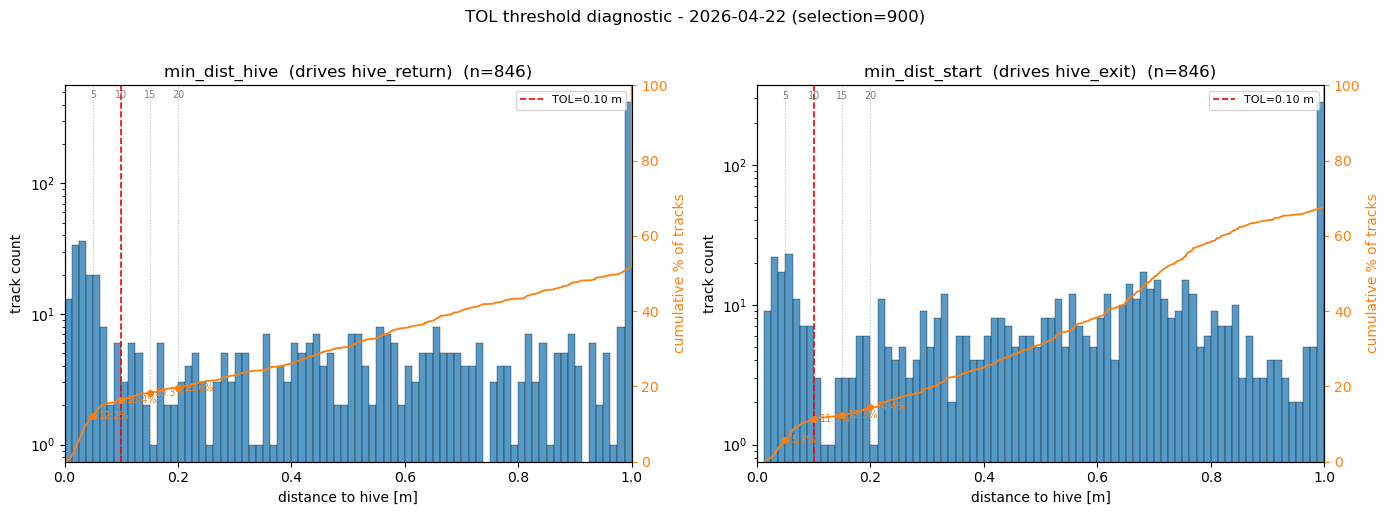


min_dist_hive  (n=846)
  TOL=0.05 m  ->    103 tracks ( 12.2%)
  TOL=0.10 m  ->    139 tracks ( 16.4%)
  TOL=0.15 m  ->    155 tracks ( 18.3%)
  TOL=0.20 m  ->    166 tracks ( 19.6%)

min_dist_start  (n=846)
  TOL=0.05 m  ->     48 tracks (  5.7%)
  TOL=0.10 m  ->     96 tracks ( 11.3%)
  TOL=0.15 m  ->    104 tracks ( 12.3%)
  TOL=0.20 m  ->    122 tracks ( 14.4%)


In [27]:
import matplotlib.pyplot as plt

# -- Controls --------------------------------------------------------------
XMAX        = 1.0          # m, histogram x-axis clip
N_BINS      = 80
LOG_Y       = True         # log y-axis on the histograms
REF_TOLS    = [0.05, 0.10, 0.15, 0.20]   # grey gridlines
# -------------------------------------------------------------------------

def _panel(ax, series, title, current_tol):
    vals = series.dropna().clip(upper=XMAX).to_numpy()
    if len(vals) == 0:
        ax.set_title(f"{title} (no data)")
        return

    bins = np.linspace(0, XMAX, N_BINS + 1)
    ax.hist(vals, bins=bins, color="tab:blue", alpha=0.75,
            edgecolor="black", linewidth=0.3)
    if LOG_Y:
        ax.set_yscale("log")
    ax.set_xlabel("distance to hive [m]")
    ax.set_ylabel("track count")
    ax.set_xlim(0, XMAX)

    # Reference TOL markers.
    for t in REF_TOLS:
        ax.axvline(t, color="grey", linestyle=":", alpha=0.5, lw=0.8)
        ax.text(t, ax.get_ylim()[1] * 0.8, f"{t*100:.0f}",
                color="grey", fontsize=7, ha="center")

    # Current TOL.
    ax.axvline(current_tol, color="red", linestyle="--", lw=1.2,
               label=f"TOL={current_tol:.2f} m")

    # CDF on twin axis.
    ax2 = ax.twinx()
    xs = np.sort(vals)
    ys = np.arange(1, len(xs) + 1) / len(xs) * 100
    ax2.plot(xs, ys, color="tab:orange", lw=1.3, label="CDF [%]")
    ax2.set_ylabel("cumulative % of tracks", color="tab:orange")
    ax2.set_ylim(0, 100)
    ax2.tick_params(axis="y", colors="tab:orange")

    # Read CDF at each reference TOL and annotate.
    for t in REF_TOLS:
        pct = float((vals <= t).mean() * 100)
        ax2.plot(t, pct, "o", color="tab:orange", markersize=4)
        ax2.text(t + 0.01, pct, f"{pct:.1f}%",
                 color="tab:orange", fontsize=7, va="center")

    ax.set_title(f"{title}  (n={len(vals)})")
    ax.legend(loc="upper right", fontsize=8)


fig, axes = plt.subplots(1, 2, figsize=(14, 5))
_panel(axes[0], results["min_dist_hive"],
       "min_dist_hive  (drives hive_return)", TOL)
_panel(axes[1], exit_results["min_dist_start"],
       "min_dist_start  (drives hive_exit)", TOL)
fig.suptitle(f"TOL threshold diagnostic - {TARGET_DATE.date()} "
             f"(selection={SPOT_SELECTION})", y=1.02)
plt.tight_layout()
plt.show()

# Text summary: count at each reference TOL.
def _table(series, name):
    vals = series.dropna()
    print(f"\n{name}  (n={len(vals)})")
    for t in REF_TOLS:
        hits = int((vals <= t).sum())
        print(f"  TOL={t:.2f} m  ->  {hits:5d} tracks "
              f"({hits / max(len(vals), 1) * 100:5.1f}%)")

_table(results["min_dist_hive"],       "min_dist_hive")
_table(exit_results["min_dist_start"], "min_dist_start")


### 11. Exit classifier v2 (velocity back-extrapolation)

`min_dist_start` doesn't separate real exits from fly-bys (no bimodal valley). Replacement: fit a velocity from the first few valid samples, extrapolate backward in time, and ask whether the line passes close to the hive in the past. This is scale-invariant - the bee can be 50 cm away on its first sample and still classify cleanly, as long as its initial trajectory points straight outward from the hive.

Rules:
- At least **HEAD_N** valid samples at the start.
- Initial speed must exceed **MIN_SPEED** (rejects hoverers / artefacts).
- The closest-approach point of the backward ray must lie **in the past** (negative `t_star`) - rejects bees flying *toward* the hive.
- `|t_star|` must be less than **MAX_LAG_S** - rejects physically absurd extrapolations.
- Closest-approach distance to the hive must be **<= EXIT_TOL_V2**.

Produces `exit_results_v2` parallel to `exit_results`. A confusion matrix and overlaid daily curves compare the two.


Exit v1 (min_dist_start <= TOL)   :   96
Exit v2 (velocity back-extrap.)   :   80
Returns (unchanged)               :  139
re_ratio v1 = 1.45
re_ratio v2 = 1.74  <- target ~1.0

v2 reason breakdown (all tracks):
reason
closest_in_future    496
too_far              173
slow                  84
ok                    80
too_much_lag          13

Confusion matrix (rows=v1, cols=v2):
v2     False  True 
v1                 
False    722     28
True      44     52


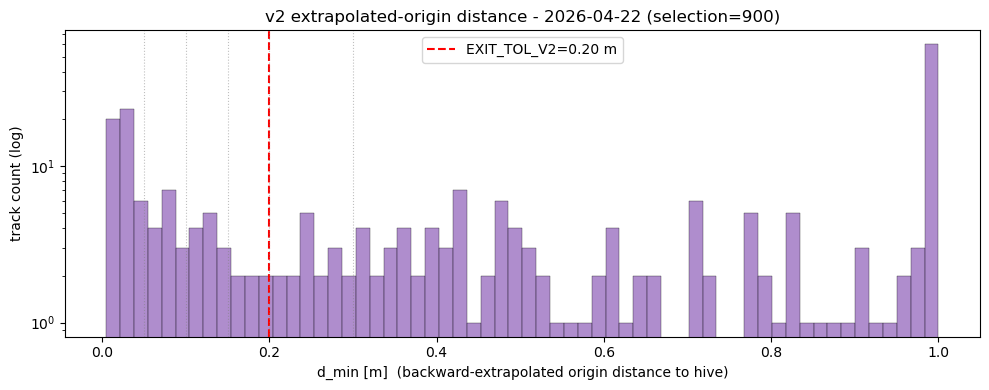

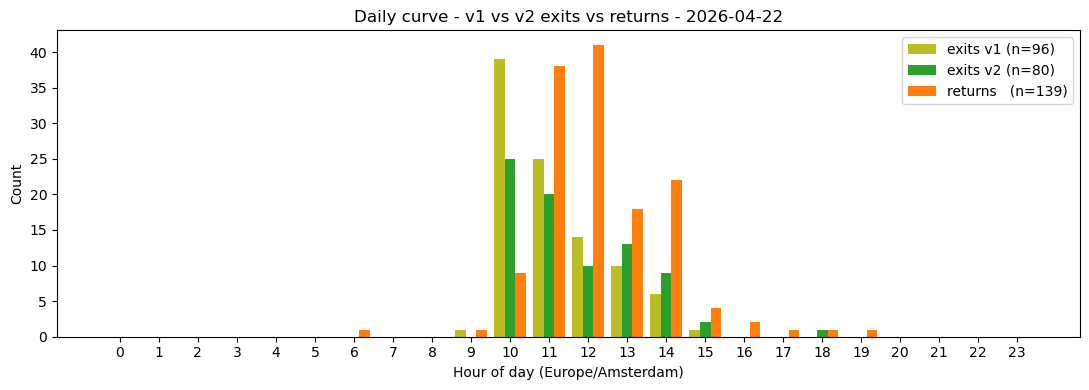

In [25]:
import matplotlib.pyplot as plt

# -- Controls --------------------------------------------------------------
HEAD_N       = 5        # samples used to fit initial velocity
EXIT_TOL_V2  = 0.20     # m  - tolerance on the back-extrapolated origin
MIN_SPEED    = 0.2      # m/s - reject slow / hovering tracks
MAX_LAG_S    = 2.0      # s   - reject implausible extrapolations
FPS          = 60.0     # PATS-C frame rate (fallback when no time column)
# -------------------------------------------------------------------------

def is_hive_exit_v2(trk, hive, head_n=HEAD_N, exit_tol=EXIT_TOL_V2,
                   min_speed=MIN_SPEED, max_lag_s=MAX_LAG_S, fps=FPS):
    """Back-extrapolate the first head_n valid samples and test whether the
    line passes within exit_tol of the hive in the recent past."""
    xyz = valid_xyz(trk)
    if xyz is None or len(xyz) < head_n:
        return False, {"reason": "short_track"}
    head = xyz[:head_n]
    p0   = head[0]

    # Linear fit per axis gives a robust velocity estimate.
    t = np.arange(head_n) / fps
    v = np.array([np.polyfit(t, head[:, k], 1)[0] for k in range(3)])
    speed = float(np.linalg.norm(v))
    if speed < min_speed:
        return False, {"reason": "slow", "speed_mps": speed}

    hive_np = np.asarray(hive, dtype=float)
    rel     = p0 - hive_np
    t_star  = -float(np.dot(v, rel)) / (speed ** 2)

    if t_star > 0:
        return False, {"reason": "closest_in_future",
                       "t_star_s": t_star, "speed_mps": speed}
    if abs(t_star) > max_lag_s:
        return False, {"reason": "too_much_lag",
                       "t_star_s": t_star, "speed_mps": speed}

    d_min = float(np.linalg.norm(p0 + v * t_star - hive_np))
    is_exit = d_min <= exit_tol
    return is_exit, {"t_star_s": t_star, "d_min_m": d_min,
                     "speed_mps": speed, "first_dist_m": float(np.linalg.norm(rel)),
                     "reason": "ok" if is_exit else "too_far"}

# -- Run classifier --------------------------------------------------------
ft_v2 = pd.read_csv(EXPORT_DIR / "flight_tracks.csv")
if "pos_valid_insect" in ft_v2.columns:
    ft_v2 = ft_v2[ft_v2["pos_valid_insect"] == 1]
sort_cols = ["detection_uid"]
for cand in ("rs_id", "time_insect", "timestamp"):
    if cand in ft_v2.columns:
        sort_cols.append(cand); break
ft_v2 = ft_v2.sort_values(sort_cols)

_det_sys = detections.set_index("uid")["system_id"]

rows = []
for uid_int, trk in ft_v2.groupby("detection_uid"):
    if "system_id" in trk.columns:
        sys_id = int(trk["system_id"].iloc[0])
    else:
        sys_id = int(_det_sys.get(int(uid_int), -1))
    if sys_id not in HIVE_BY_SYSTEM:
        continue
    hive = HIVE_BY_SYSTEM[sys_id]
    is_exit, diag = is_hive_exit_v2(trk, hive)
    rows.append({"uid": int(uid_int), "system_id": sys_id,
                 "hive_exit_v2": is_exit, **diag})

exit_results_v2 = pd.DataFrame(rows)

# -- Summary ---------------------------------------------------------------
n_v1 = int(exit_results["hive_exit"].sum())
n_v2 = int(exit_results_v2["hive_exit_v2"].sum())
n_ret = int(results["hive_return"].sum())

print(f"Exit v1 (min_dist_start <= TOL)   : {n_v1:4d}")
print(f"Exit v2 (velocity back-extrap.)   : {n_v2:4d}")
print(f"Returns (unchanged)               : {n_ret:4d}")
if n_v1 > 0:
    print(f"re_ratio v1 = {n_ret/n_v1:.2f}")
if n_v2 > 0:
    print(f"re_ratio v2 = {n_ret/n_v2:.2f}  <- target ~1.0")

# Reason breakdown for rejected tracks (v2).
print("\nv2 reason breakdown (all tracks):")
print(exit_results_v2["reason"].value_counts().to_string())

# -- Confusion matrix v1 vs v2 --------------------------------------------
compare = (exit_results[["uid", "hive_exit"]]
           .merge(exit_results_v2[["uid", "hive_exit_v2"]],
                  on="uid", how="outer"))
compare["hive_exit"]    = compare["hive_exit"].fillna(False)
compare["hive_exit_v2"] = compare["hive_exit_v2"].fillna(False)

ct = pd.crosstab(compare["hive_exit"], compare["hive_exit_v2"],
                 rownames=["v1"], colnames=["v2"])
print("\nConfusion matrix (rows=v1, cols=v2):")
print(ct.to_string())

# -- d_min_m histogram (v2 equivalent of the TOL diagnostic) --------------
dmin_ok = exit_results_v2.loc[exit_results_v2["d_min_m"].notna(), "d_min_m"]

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(dmin_ok.clip(upper=1.0), bins=60, color="tab:purple",
        alpha=0.75, edgecolor="black", linewidth=0.3)
ax.axvline(EXIT_TOL_V2, color="red", linestyle="--",
           label=f"EXIT_TOL_V2={EXIT_TOL_V2:.2f} m")
for t in (0.05, 0.10, 0.15, 0.20, 0.30):
    ax.axvline(t, color="grey", ls=":", alpha=0.5, lw=0.8)
ax.set_yscale("log")
ax.set_xlabel("d_min [m]  (backward-extrapolated origin distance to hive)")
ax.set_ylabel("track count (log)")
ax.set_title(f"v2 extrapolated-origin distance - {TARGET_DATE.date()} "
             f"(selection={SPOT_SELECTION})")
ax.legend()
plt.tight_layout()
plt.show()

# -- Daily curve overlay: v1 vs v2 exits ----------------------------------
# Build a per-uid timestamp lookup.
_ts = pd.to_datetime(detections["datetime"],
                     format="%Y%m%d_%H%M%S", errors="coerce")
_ts = pd.DataFrame({"uid": detections["uid"], "ts": _ts})
_ts = _ts.dropna().drop_duplicates("uid")

def _hourly(flagged_uids):
    s = _ts[_ts["uid"].isin(flagged_uids)]["ts"]
    return s.dt.hour.value_counts().reindex(range(24), fill_value=0)

uids_v1 = exit_results.loc[exit_results["hive_exit"],     "uid"]
uids_v2 = exit_results_v2.loc[exit_results_v2["hive_exit_v2"], "uid"]
uids_r  = results.loc[results["hive_return"], "uid"]

hv1 = _hourly(uids_v1)
hv2 = _hourly(uids_v2)
hr  = _hourly(uids_r)

fig, ax = plt.subplots(figsize=(11, 4))
x = np.arange(24); w = 0.28
ax.bar(x - w, hv1.values, width=w, color="tab:olive",
       label=f"exits v1 (n={int(hv1.sum())})")
ax.bar(x,     hv2.values, width=w, color="tab:green",
       label=f"exits v2 (n={int(hv2.sum())})")
ax.bar(x + w, hr.values,  width=w, color="tab:orange",
       label=f"returns   (n={int(hr.sum())})")
ax.set_xticks(x)
ax.set_xlabel("Hour of day (Europe/Amsterdam)")
ax.set_ylabel("Count")
ax.set_title(f"Daily curve - v1 vs v2 exits vs returns "
             f"- {TARGET_DATE.date()}")
ax.legend()
plt.tight_layout()
plt.show()


### 12. v1-vs-v2 disagreement viewer

Three side-by-side 3D sub-plots, each showing N random flight tracks from one bucket of the v1/v2 confusion matrix:

- **both** - v1 True AND v2 True. High-confidence exits. These are your ground-truth "canonical exit" shape.
- **v1-only** - v1 True AND v2 False. Tracks v1 flagged but v2 rejected. Are these real exits (so v2 is too strict) or returns/hoverers starting near the hive (so v1 is too permissive)?
- **v2-only** - v1 False AND v2 True. Tracks v2 caught that v1 missed - typically exits whose first valid sample is already >TOL out.

Hive marker in red, track-start in green, track-end in orange.

**How to read it.** If **v1-only** tracks *start* near the hive and move *toward* it or sideways - those are returns/hoverers; v2 is right to reject them, and v1 was inflating the exit count. If **v1-only** tracks start near the hive and fan outward - v2 is being too strict and we need to loosen `MIN_SPEED` or `EXIT_TOL_V2`. If **v2-only** tracks start well away from the hive but their shape clearly traces back to it - v2 is earning its keep.


both (v1 & v2)  :   52 tracks total
v1-only         :   44 tracks total
v2-only         :   28 tracks total


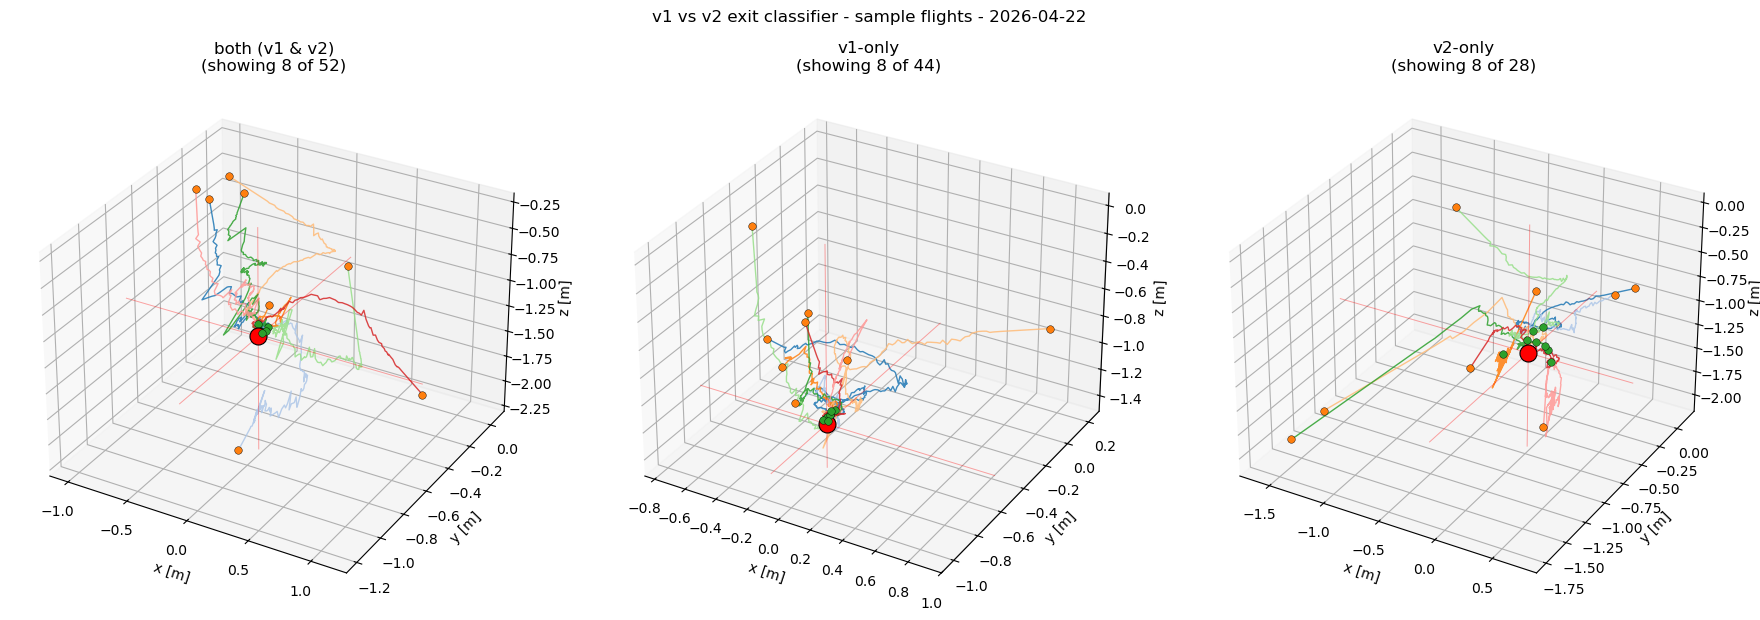

In [26]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

# -- Controls --------------------------------------------------------------
N_PER_BUCKET = 8        # tracks to plot per sub-plot
RANDOM_SEED  = 0        # same seed each run -> same sample; bump for fresh ones
PADDING      = 0.20     # m, slack around the plotted bounding box
CLIP_RADIUS  = 3.0      # m, drop points further than this from the hive
# -------------------------------------------------------------------------

# --- 1. Align v1 and v2 flags per uid. --------------------------------------
# exit_results has (uid, hive_exit); exit_results_v2 has (uid, hive_exit_v2).
# Outer merge keeps every uid from either frame; missing values fill to False
# so we can do boolean logic without NaN-handling surprises.
flags = (exit_results[["uid", "hive_exit"]]
         .merge(exit_results_v2[["uid", "hive_exit_v2"]],
                on="uid", how="outer"))
flags["hive_exit"]    = flags["hive_exit"].fillna(False).astype(bool)
flags["hive_exit_v2"] = flags["hive_exit_v2"].fillna(False).astype(bool)

# --- 2. Build the three buckets via boolean masks. --------------------------
# & = AND, | = OR, ~ = NOT. These are element-wise pandas Series operators.
buckets = {
    "both (v1 & v2)": flags[flags["hive_exit"] & flags["hive_exit_v2"]],
    "v1-only":        flags[flags["hive_exit"] & ~flags["hive_exit_v2"]],
    "v2-only":        flags[~flags["hive_exit"] & flags["hive_exit_v2"]],
}
for name, df in buckets.items():
    print(f"{name:16s}: {len(df):4d} tracks total")

# --- 3. Sample reproducibly from each bucket. -------------------------------
# df.sample(n, random_state=SEED) returns the same rows every time for the
# same seed - important so that "re-running the cell" doesn't shuffle things.
sampled = {}
for name, df in buckets.items():
    n = min(N_PER_BUCKET, len(df))
    sampled[name] = (df.sample(n=n, random_state=RANDOM_SEED)
                     if n > 0 else df.head(0))

# --- 4. Load flight_tracks once (no need to re-read per bucket). ------------
ft_cmp = pd.read_csv(EXPORT_DIR / "flight_tracks.csv")
if "pos_valid_insect" in ft_cmp.columns:
    ft_cmp = ft_cmp[ft_cmp["pos_valid_insect"] == 1]
# Pre-index by detection_uid for O(1) lookups instead of scanning the whole
# DataFrame for each track.
ft_by_uid = {uid: g for uid, g in ft_cmp.groupby("detection_uid")}

# --- 5. Decide which hive(s) to draw. --------------------------------------
if SPOT_SELECTION == "both":
    hives_to_show = [("hive 900", hive_900_pos),
                     ("hive 939", hive_939_pos)]
else:
    hives_to_show = [(f"hive {SPOT_SELECTION}", HIVE_POS)]
hive_arr = np.stack([h for _, h in hives_to_show])

# --- 6. Three 3D subplots side by side. ------------------------------------
# subplot_kw={"projection": "3d"} turns each axes into a 3D one. Without
# this you get 2D axes that can't do .plot(x, y, z).
fig, axes = plt.subplots(1, 3, figsize=(18, 6),
                         subplot_kw=dict(projection="3d"))
cmap = plt.get_cmap("tab20")

def _draw_hive(ax, pos, label, xlim, ylim, zlim):
    """Hive cross-hair + big red dot. Drawn LAST (after tracks) so the dot
    isn\'t swallowed by matplotlib\'s unreliable 3D z-ordering."""
    ax.plot(xlim, [pos[1]]*2, [pos[2]]*2, c="red", lw=0.7, alpha=0.35)
    ax.plot([pos[0]]*2, ylim, [pos[2]]*2, c="red", lw=0.7, alpha=0.35)
    ax.plot([pos[0]]*2, [pos[1]]*2, zlim, c="red", lw=0.7, alpha=0.35)
    ax.scatter(pos[0], pos[1], pos[2], c="red", marker="o", s=150,
               edgecolors="black", linewidths=0.8, label=label,
               depthshade=False)

for ax, (bucket_name, sample_df) in zip(axes, sampled.items()):
    uids = sample_df["uid"].astype(int).tolist()
    plotted_pts = []

    for i, uid in enumerate(uids):
        trk = ft_by_uid.get(uid)
        if trk is None or trk.empty:
            continue
        xyz = trk[["posX_insect", "posY_insect", "posZ_insect"]].to_numpy(float)

        # Clip samples far from any hive so one glitch doesn\'t stretch
        # the bounding box and shrink the hive to a pixel.
        dists = np.min(np.linalg.norm(
            xyz[:, None, :] - hive_arr[None, :, :], axis=-1), axis=1)
        keep = dists <= CLIP_RADIUS
        plotted_pts.append(xyz[keep])

        color = cmap(i % 20)
        ax.plot(xyz[:, 0], xyz[:, 1], xyz[:, 2], color=color, lw=1.0, alpha=0.85)
        # Start = green, end = orange
        ax.scatter(xyz[0, 0], xyz[0, 1], xyz[0, 2],
                   color="tab:green", s=30,
                   edgecolors="black", linewidths=0.3)
        ax.scatter(xyz[-1, 0], xyz[-1, 1], xyz[-1, 2],
                   color="tab:orange", s=30,
                   edgecolors="black", linewidths=0.3)

    # --- 7. Fit the axes to what we just plotted (+ padding). --------------
    if plotted_pts:
        all_pts = np.vstack(plotted_pts + [hive_arr])
    else:
        all_pts = hive_arr
    lo = all_pts.min(axis=0) - PADDING
    hi = all_pts.max(axis=0) + PADDING
    xlim = (lo[0], hi[0]); ylim = (lo[1], hi[1]); zlim = (lo[2], hi[2])
    ax.set_xlim(xlim); ax.set_ylim(ylim); ax.set_zlim(zlim)

    # --- 8. Hive on top. ----------------------------------------------------
    for lbl, pos in hives_to_show:
        _draw_hive(ax, pos, lbl, xlim, ylim, zlim)

    ax.set_xlabel("x [m]"); ax.set_ylabel("y [m]"); ax.set_zlabel("z [m]")
    ax.set_title(f"{bucket_name}\n(showing {len(uids)} of "
                 f"{len(buckets[bucket_name])})")

fig.suptitle(f"v1 vs v2 exit classifier - sample flights "
             f"- {TARGET_DATE.date()}", y=1.02)
plt.tight_layout()
plt.show()


### 13. Exit classifier v3 (hybrid) + re-derived indicators

`v1` over-counts (flags hoverers/returns whose first sample happens to sit near the hive). `v2` under-counts (kills real exits when the initial velocity is jittery). A naive union inherits v1's false positives. This hybrid uses v2 as the primary signal but lets v1 rescue tracks that v2 could not confidently classify - never the ones v2 actively rejects on geometric grounds.

**Rule**
```
hive_exit_v3 = hive_exit_v2  OR  (hive_exit  AND  v2_reason in {"slow", "short_track"})
```

`"closest_in_future"`, `"too_far"`, `"too_much_lag"` are **strong** rejections (the trajectory evidence says this is not an exit). We trust those and never let v1 overrule. `"slow"` and `"short_track"` are **weak** rejections (v2 had no data to form an opinion). On those, v1's first-sample-near-hive heuristic gets the benefit of the doubt.

The rest of this cell: build `hive_exit_v3`, summarise how the three classifiers compare, and re-derive re_ratio + trip_duration + daily_curve using v3 so you can see the effect downstream.


Counts (selection='900', date=2026-04-22)
  v1 exits          :   96
  v2 exits          :   80
  v3 (hybrid)       :  115
  returns           :  139

  re_ratio v1       : 1.45
  re_ratio v2       : 1.74
  re_ratio v3       : 1.21  <- target ~1.0

Hybrid composition:
  from v2 directly          : 80
  rescued via v1 (weak v2)  : 35
  rescue reasons breakdown  :
reason
slow    35

Trip duration v3          : n_matched=115  median=1955.0s  mean=1734.9s  p95=3202.6s


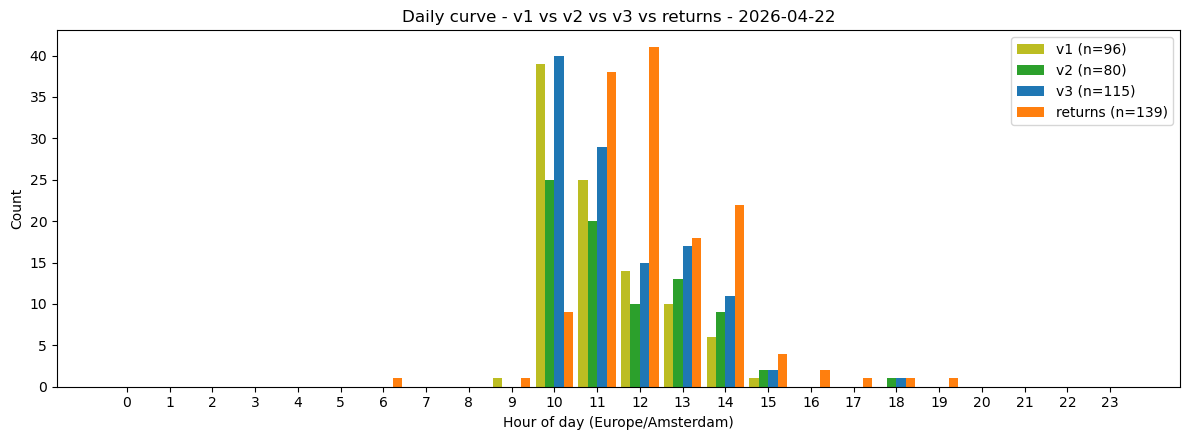

In [27]:
import matplotlib.pyplot as plt

STRONG_NO = {"closest_in_future", "too_far", "too_much_lag"}
WEAK_NO   = {"slow", "short_track"}

# --- 1. Build per-uid frame with v1 / v2 flag + v2 reason -----------------
merged = (exit_results[["uid", "hive_exit"]]
          .merge(exit_results_v2[["uid", "hive_exit_v2", "reason"]],
                 on="uid", how="outer"))
merged["hive_exit"]    = merged["hive_exit"].fillna(False).astype(bool)
merged["hive_exit_v2"] = merged["hive_exit_v2"].fillna(False).astype(bool)
merged["reason"]       = merged["reason"].fillna("no_v2")

# --- 2. Hybrid v3 ---------------------------------------------------------
rescue = merged["hive_exit"] & merged["reason"].isin(WEAK_NO | {"no_v2"})
merged["hive_exit_v3"] = merged["hive_exit_v2"] | rescue

# Promote to a standalone DataFrame so downstream code can use it.
exit_results_v3 = merged[["uid", "hive_exit_v3"]].copy()

# --- 3. Summary -----------------------------------------------------------
n_v1 = int(merged["hive_exit"].sum())
n_v2 = int(merged["hive_exit_v2"].sum())
n_v3 = int(merged["hive_exit_v3"].sum())
n_ret = int(results["hive_return"].sum())

print("Counts (selection="  f"{SPOT_SELECTION!r}, date={TARGET_DATE.date()})")
print(f"  v1 exits          : {n_v1:4d}")
print(f"  v2 exits          : {n_v2:4d}")
print(f"  v3 (hybrid)       : {n_v3:4d}")
print(f"  returns           : {n_ret:4d}")
print()
print(f"  re_ratio v1       : {n_ret/n_v1:.2f}" if n_v1 else "  re_ratio v1 : n/a")
print(f"  re_ratio v2       : {n_ret/n_v2:.2f}" if n_v2 else "  re_ratio v2 : n/a")
print(f"  re_ratio v3       : {n_ret/n_v3:.2f}  <- target ~1.0" if n_v3 else "  re_ratio v3 : n/a")

# How was v3 built?
rescued = int(rescue.sum())
print(f"\nHybrid composition:")
print(f"  from v2 directly          : {n_v2}")
print(f"  rescued via v1 (weak v2)  : {rescued}")
print(f"  rescue reasons breakdown  :")
print(merged.loc[rescue, "reason"].value_counts().to_string())

# --- 4. Re-derived indicators with v3 -------------------------------------
# One table: one row per uid with timestamp + the chosen exit flag + return flag.
_meta = detections[["uid", "datetime", "system_id"]].copy()
_meta["ts"] = pd.to_datetime(_meta["datetime"],
                             format="%Y%m%d_%H%M%S", errors="coerce")

events = (_meta
          .merge(results[["uid", "hive_return"]],   on="uid", how="left")
          .merge(exit_results_v3[["uid", "hive_exit_v3"]], on="uid", how="left"))
events["hive_return"]  = events["hive_return"].fillna(False)
events["hive_exit_v3"] = events["hive_exit_v3"].fillna(False)

# Trip duration (greedy per-camera match) using v3 exits.
_ex  = events[events["hive_exit_v3"] == True].sort_values("ts")
_rt  = events[events["hive_return"]   == True].sort_values("ts")
trip_rows = []
for sys_id in sorted(events["system_id"].dropna().unique()):
    g_ex = _ex[_ex["system_id"] == sys_id]
    g_rt = _rt[_rt["system_id"] == sys_id]
    used = set()
    for _, ex in g_ex.iterrows():
        cand = g_rt[(g_rt["ts"] > ex["ts"]) & (~g_rt["uid"].isin(used))]
        if cand.empty: continue
        rt = cand.iloc[0]
        trip_rows.append({"trip_seconds": (rt["ts"] - ex["ts"]).total_seconds()})
        used.add(rt["uid"])
trips_v3 = pd.DataFrame(trip_rows)
if not trips_v3.empty:
    s = trips_v3["trip_seconds"]
    print(f"\nTrip duration v3          : n_matched={len(trips_v3)}  "
          f"median={s.median():.1f}s  mean={s.mean():.1f}s  "
          f"p95={s.quantile(0.95):.1f}s")

# --- 5. Overlay daily curves: v1 / v2 / v3 exits + returns ----------------
def _hourly(uids):
    s = _meta[_meta["uid"].isin(uids)]["ts"]
    return s.dt.hour.value_counts().reindex(range(24), fill_value=0)

uids_v1 = exit_results.loc[exit_results["hive_exit"], "uid"]
uids_v2 = exit_results_v2.loc[exit_results_v2["hive_exit_v2"], "uid"]
uids_v3 = exit_results_v3.loc[exit_results_v3["hive_exit_v3"], "uid"]
uids_r  = results.loc[results["hive_return"], "uid"]

h1, h2, h3, hr = _hourly(uids_v1), _hourly(uids_v2), _hourly(uids_v3), _hourly(uids_r)

fig, ax = plt.subplots(figsize=(12, 4.5))
x = np.arange(24); w = 0.22
ax.bar(x - 1.5*w, h1.values, width=w, color="tab:olive",  label=f"v1 (n={int(h1.sum())})")
ax.bar(x - 0.5*w, h2.values, width=w, color="tab:green",  label=f"v2 (n={int(h2.sum())})")
ax.bar(x + 0.5*w, h3.values, width=w, color="tab:blue",   label=f"v3 (n={int(h3.sum())})")
ax.bar(x + 1.5*w, hr.values, width=w, color="tab:orange", label=f"returns (n={int(hr.sum())})")
ax.set_xticks(x)
ax.set_xlabel("Hour of day (Europe/Amsterdam)")
ax.set_ylabel("Count")
ax.set_title(f"Daily curve - v1 vs v2 vs v3 vs returns - {TARGET_DATE.date()}")
ax.legend()
plt.tight_layout()
plt.show()


### 14. Multi-day validation sweep (v1 / v2 / v3)

Runs all three classifiers across every `(date, system_id)` combination already on disk, directly from `cache/flight_data_<date>_system_<id>/`. No API calls, no re-fetch. Produces one row per (date, system) with:

- `n_tracks`, `n_returns`, `n_v1`, `n_v2`, `n_v3`
- `re_ratio` for each (target ~1.0)
- `median_trip_s` (trip-duration median using v3 exits)
- `night_count` (any exits/returns flagged between 22:00 and 05:00 - should be 0)

Two plots below the table: re_ratio trend across days, and per-day n_exits comparison. If a classifier is stable, its line should be flat-ish near 1.0. If it swings (e.g. 0.6 on Monday, 2.3 on Tuesday), something is drifting - camera calibration, tracker quality, or biological (but colony behaviour usually doesn't double in a day).


Sweeping cache: /Users/jaspe/Projects/Claude/Bumblebee-monitoring/src/flight_analysis/pats/cache

=== multi-day sweep ===

      date  system_id  n_tracks  n_returns  n_v1  n_v2  n_v3  re_ratio_v1  re_ratio_v2  re_ratio_v3  median_trip_s  n_matched  night_count
2026-04-19        900      1080        226   129    30   150     1.751938     7.533333     1.506667          928.5        150            0
2026-04-21        900        21          0     0     1     1          NaN     0.000000     0.000000            NaN          0            0
2026-04-21        939         0          0     0     0     0          NaN          NaN          NaN            NaN          0            0
2026-04-22        900       846        139    93    25   110     1.494624     5.560000     1.263636         2156.5        110            0
2026-04-22        939       659         91    74    26    87     1.229730     3.500000     1.045977         4117.0         86            0
2026-04-23        900         0          0 

/var/folders/qf/04n5tyxx79l0r05973_1fp9m0000gn/T/ipykernel_92659/1609027904.py:164: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(sub["date"], rotation=30, ha="right")
/var/folders/qf/04n5tyxx79l0r05973_1fp9m0000gn/T/ipykernel_92659/1609027904.py:164: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(sub["date"], rotation=30, ha="right")


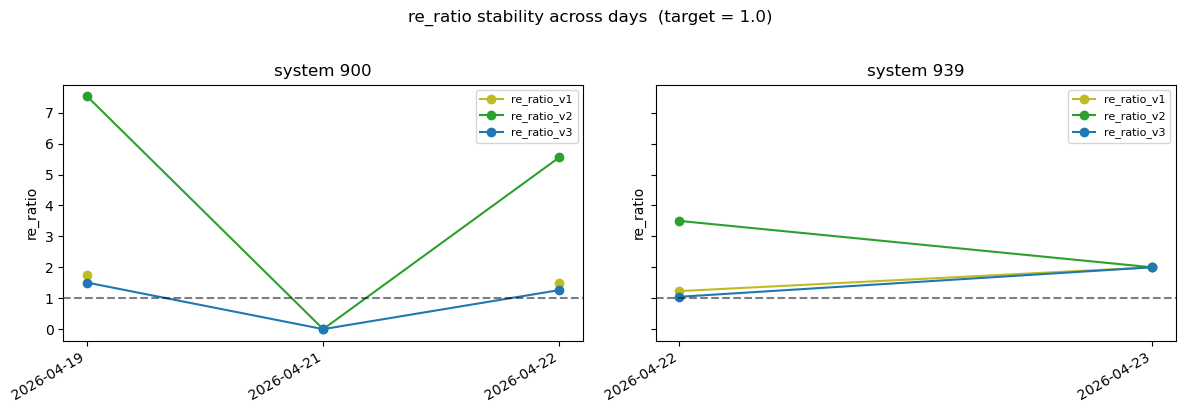

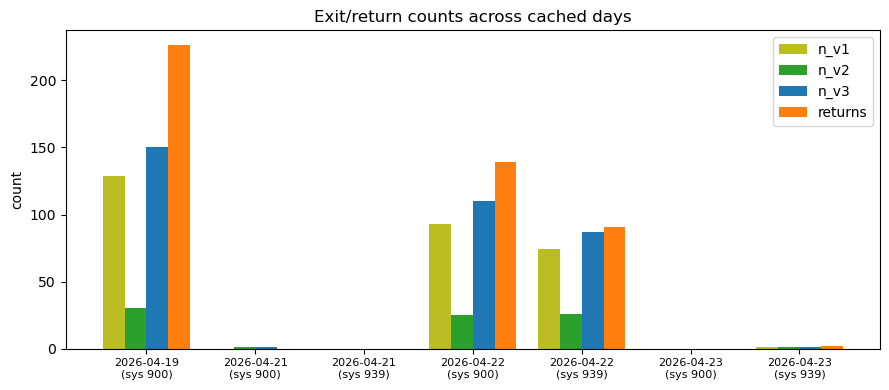

In [28]:
import matplotlib.pyplot as plt
import re
from pathlib import Path

# The cache lives next to the notebook. EXPORT_DIR already points at today's
# export folder, but for sweeping we want the root cache directory.
CACHE_BASE = Path("cache")
if not CACHE_BASE.exists():
    # Notebook might be run from a different cwd - fall back to the parent of
    # EXPORT_DIR.
    CACHE_BASE = EXPORT_DIR.parent
print(f"Sweeping cache: {CACHE_BASE.resolve()}")

# -- Self-contained classifier helpers (mirror the notebook's definitions) --
STRONG_NO = {"closest_in_future", "too_far", "too_much_lag"}
WEAK_NO   = {"slow", "short_track"}

def _valid_xyz(trk):
    if "pos_valid_insect" in trk.columns:
        trk = trk[trk["pos_valid_insect"] == 1]
    if len(trk) == 0:
        return None
    return trk[["posX_insect", "posY_insect", "posZ_insect"]].to_numpy(dtype=float)

def _is_return(xyz, hive, tol, tail=10):
    if xyz is None or len(xyz) == 0:
        return False, np.nan
    tail_xyz = xyz[-tail:]
    d = np.min(np.linalg.norm(tail_xyz - hive, axis=1))
    return bool(d <= tol), float(d)

def _is_exit_v1(xyz, hive, tol):
    if xyz is None or len(xyz) == 0:
        return False, np.nan
    d = float(np.linalg.norm(xyz[0] - hive))
    return bool(d <= tol), d

def _is_exit_v2(xyz, hive, head_n=5, exit_tol=0.20,
                min_speed=0.5, max_lag_s=2.0, fps=60.0):
    if xyz is None or len(xyz) < head_n:
        return False, "short_track"
    head = xyz[:head_n]
    p0 = head[0]
    t = np.arange(head_n) / fps
    v = np.array([np.polyfit(t, head[:, k], 1)[0] for k in range(3)])
    speed = float(np.linalg.norm(v))
    if speed < min_speed:
        return False, "slow"
    rel = p0 - hive
    t_star = -float(np.dot(v, rel)) / (speed ** 2)
    if t_star > 0:
        return False, "closest_in_future"
    if abs(t_star) > max_lag_s:
        return False, "too_much_lag"
    d_min = float(np.linalg.norm(p0 + v * t_star - hive))
    return (d_min <= exit_tol, "ok" if d_min <= exit_tol else "too_far")

# -- Sweep loop ------------------------------------------------------------
pat = re.compile(r"flight_data_(\d{4}-\d{2}-\d{2})_system_(\d+)$")

rows = []
for d in sorted(CACHE_BASE.glob("flight_data_*_system_*")):
    m = pat.match(d.name)
    if not m:
        continue
    date_str, sys_str = m.groups()
    sys_id = int(sys_str)
    if sys_id not in HIVE_BY_SYSTEM:
        continue

    det_csv    = d / "detections.csv"
    tracks_dir = d / "tracks"
    if not det_csv.exists() or not tracks_dir.exists():
        continue

    dets = pd.read_csv(det_csv)
    dets["ts"] = pd.to_datetime(dets["datetime"],
                                format="%Y%m%d_%H%M%S", errors="coerce")

    hive = np.asarray(HIVE_BY_SYSTEM[sys_id])

    n_tracks = n_ret = n_v1 = n_v2 = n_v3 = 0
    exit_ts_v3 = []   # for trip-duration + night count
    return_ts  = []

    for _, det in dets.iterrows():
        uid = int(det["uid"])
        trk_path = tracks_dir / f"{uid}.csv"
        if not trk_path.exists():
            continue
        trk = pd.read_csv(trk_path)
        xyz = _valid_xyz(trk)
        if xyz is None or len(xyz) == 0:
            continue
        n_tracks += 1

        is_ret, _  = _is_return(xyz, hive, TOL)
        is_v1, _   = _is_exit_v1(xyz, hive, TOL)
        is_v2, rsn = _is_exit_v2(xyz, hive)
        is_v3 = is_v2 or (is_v1 and rsn in (WEAK_NO | {"no_v2"}))

        if is_ret:
            n_ret += 1
            return_ts.append(det["ts"])
        if is_v1: n_v1 += 1
        if is_v2: n_v2 += 1
        if is_v3:
            n_v3 += 1
            exit_ts_v3.append(det["ts"])

    # Trip duration (greedy) with v3 exits.
    ex_sorted = sorted(t for t in exit_ts_v3 if pd.notna(t))
    rt_sorted = sorted(t for t in return_ts  if pd.notna(t))
    used, trips = [False]*len(rt_sorted), []
    for et in ex_sorted:
        for j, rt in enumerate(rt_sorted):
            if used[j] or rt <= et:
                continue
            trips.append((rt - et).total_seconds())
            used[j] = True
            break
    median_trip = float(np.median(trips)) if trips else np.nan

    # Night-time activity (22:00 - 05:00 Amsterdam).
    def _is_night(ts):
        h = ts.hour
        return (h >= 22) or (h < 5)
    night = sum(1 for t in (exit_ts_v3 + return_ts)
                if pd.notna(t) and _is_night(t))

    rows.append({
        "date":          date_str,
        "system_id":     sys_id,
        "n_tracks":      n_tracks,
        "n_returns":     n_ret,
        "n_v1":          n_v1,
        "n_v2":          n_v2,
        "n_v3":          n_v3,
        "re_ratio_v1":   (n_ret / n_v1) if n_v1 else np.nan,
        "re_ratio_v2":   (n_ret / n_v2) if n_v2 else np.nan,
        "re_ratio_v3":   (n_ret / n_v3) if n_v3 else np.nan,
        "median_trip_s": median_trip,
        "n_matched":     len(trips),
        "night_count":   night,
    })

sweep_df = pd.DataFrame(rows).sort_values(["date", "system_id"]).reset_index(drop=True)
print("\n=== multi-day sweep ===\n")
print(sweep_df.to_string(index=False))

# -- Plots -----------------------------------------------------------------
if not sweep_df.empty:
    # (a) re_ratio trend, one line per classifier, faceted by system
    systems = sorted(sweep_df["system_id"].unique())
    fig, axes = plt.subplots(1, len(systems), figsize=(6 * len(systems), 4),
                              sharey=True, squeeze=False)
    for ax, sid in zip(axes[0], systems):
        sub = sweep_df[sweep_df["system_id"] == sid]
        for col, color in [("re_ratio_v1", "tab:olive"),
                           ("re_ratio_v2", "tab:green"),
                           ("re_ratio_v3", "tab:blue")]:
            ax.plot(sub["date"], sub[col], "o-", color=color, label=col)
        ax.axhline(1.0, color="black", ls="--", alpha=0.5)
        ax.set_xticklabels(sub["date"], rotation=30, ha="right")
        ax.set_title(f"system {sid}")
        ax.set_ylabel("re_ratio")
        ax.legend(fontsize=8)
    fig.suptitle("re_ratio stability across days  (target = 1.0)", y=1.02)
    plt.tight_layout()
    plt.show()

    # (b) absolute counts side-by-side
    fig, ax = plt.subplots(figsize=(max(9, len(sweep_df) * 0.8), 4))
    x = np.arange(len(sweep_df)); w = 0.2
    ax.bar(x - 1.5*w, sweep_df["n_v1"],      width=w, color="tab:olive",  label="n_v1")
    ax.bar(x - 0.5*w, sweep_df["n_v2"],      width=w, color="tab:green",  label="n_v2")
    ax.bar(x + 0.5*w, sweep_df["n_v3"],      width=w, color="tab:blue",   label="n_v3")
    ax.bar(x + 1.5*w, sweep_df["n_returns"], width=w, color="tab:orange", label="returns")
    ax.set_xticks(x)
    ax.set_xticklabels(
        [f"{r.date}\n(sys {r.system_id})" for r in sweep_df.itertuples()],
        rotation=0, fontsize=8)
    ax.set_ylabel("count")
    ax.set_title("Exit/return counts across cached days")
    ax.legend()
    plt.tight_layout()
    plt.show()


### 15. Activate v3 as the default classifier

The sweep (section 14) confirmed v3 is the stable one. This cell promotes it to **THE** exit classifier: every downstream indicator that reads `exit_results["hive_exit"]` now sees v3's answers instead of v1's. No other cell needs to change.

**What happens**
- v1's original output is preserved under `exit_results_v1` (so we can still diff).
- `exit_results` is overwritten to point at v3, with the column renamed from `hive_exit_v3` back to `hive_exit`. That's the column name the rest of the notebook expects.
- Re-run sections 6 (foraging indicators) and 7 (summary) after this cell and you'll see v3 numbers everywhere.

**Using on new data.** When you download a new day, run the notebook top-to-bottom. Sections 11 and 13 rebuild `exit_results_v2` / `exit_results_v3`, this cell re-points `exit_results` at v3, and the indicators update automatically. If you ever want to A/B against v1, just load `exit_results_v1` — it's still there.


In [ ]:
# --- Preserve v1 ---------------------------------------------------------
exit_results_v1 = exit_results.copy()

# --- Promote v3 to the canonical exit_results ---------------------------
exit_results = (exit_results_v3[["uid", "hive_exit_v3"]]
                .rename(columns={"hive_exit_v3": "hive_exit"})
                .copy())

print(f"Active classifier: v3")
print(f"  exit_results     : {len(exit_results)} rows, "
      f"{int(exit_results['hive_exit'].sum())} exits")
print(f"  exit_results_v1  : {len(exit_results_v1)} rows, "
      f"{int(exit_results_v1['hive_exit'].sum())} exits (kept for reference)")
print()
print("Re-run sections 6 (foraging indicators) and 7 (summary) to see v3 numbers.")
